# Analisis Exploratorio de Datos - Prediccion de Precios de Casas

## Objetivo
Desarrollar un EDA completo, entendible y orientado a modelado para `SalePrice`, conectando cada hallazgo con decisiones de preprocesamiento y seleccion de modelos.

## Hoja de ruta del cuaderno
1. Carga y perfilado inicial del dataset
2. Analisis univariado (numerico y categorico)
3. Analisis bivariado con `SalePrice`
4. Relacion multivariada y multicolinealidad
5. Cierre model-ready (calidad de datos, outliers, pipeline y features)
6. Seccion guia para modelos predictivos



In [42]:
# Importar librerias necesarias
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

# Configuracion visual global del cuaderno
sns.set_theme(style="whitegrid", context="notebook", palette="crest")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)

## 1. Carga y exploracion inicial

Exploracion superficial del dataset: dimensiones, tipos de datos y deteccion general de valores faltantes.

In [43]:
# Cargar el conjunto de datos
df = pd.read_csv(r'..\data\raw\train.csv')

# Mostrar información básica del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPrimeras 5 filas del dataset:")

with pd.option_context('display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
    display(df.head(10))

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 1460 filas × 81 columnas

Primeras 5 filas del dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,

In [44]:
# Información detallada sobre tipos de datos y valores faltantes
print("\n" + "=" * 80)
print("TIPOS DE DATOS Y VALORES FALTANTES")
print("=" * 80)
print(df.info())

print("\n" + "-" * 80)
print("RESUMEN DE VALORES FALTANTES")
print("-" * 80)
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values('Valores_Faltantes', ascending=False)
if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print("No hay valores faltantes en el dataset")


TIPOS DE DATOS Y VALORES FALTANTES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1

In [45]:
# Estadísticas descriptivas de variables numéricas
print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
df.describe().T


ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


Resumen superficial de completitud (top 15 columnas con mas faltantes):


,column,dtype,missing_pct
72,PoolQC,object,99.520548
74,MiscFeature,object,96.301370
6,Alley,object,93.767123
73,Fence,object,80.753425
25,MasVnrType,object,59.726027
57,FireplaceQu,object,47.260274
3,LotFrontage,float64,17.739726
63,GarageQual,object,5.547945
60,GarageFinish,object,5.547945
58,GarageType,object,5.547945


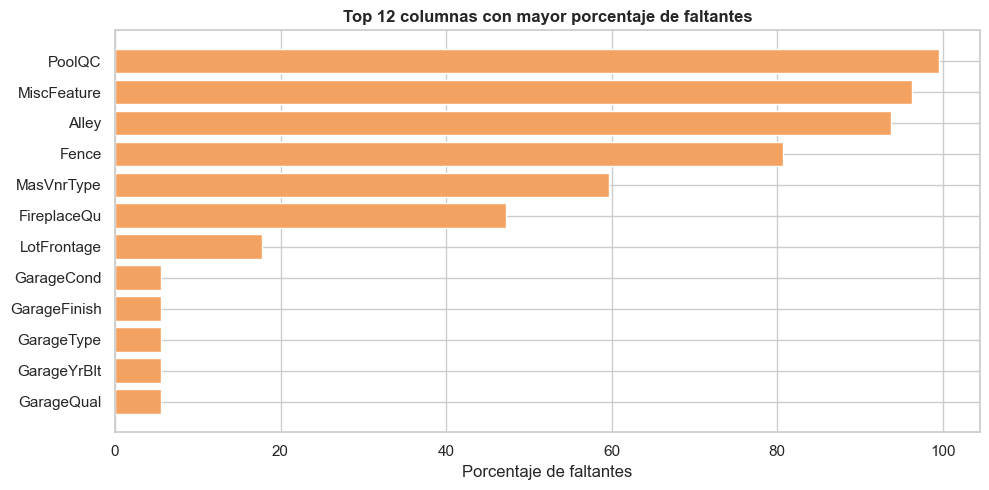

In [46]:
# Vista rapida de completitud por tipo de variable (sin entrar aun en tratamiento)
missing_by_col = df.isna().mean() * 100

overview_missing = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_pct": missing_by_col.values,
}).sort_values("missing_pct", ascending=False)

print("Resumen superficial de completitud (top 15 columnas con mas faltantes):")
display(overview_missing.head(15))

plt.figure(figsize=(10, 5))
plot_df = overview_missing.head(12).sort_values("missing_pct", ascending=True)
plt.barh(plot_df["column"], plot_df["missing_pct"], color="#f4a261")
plt.title("Top 12 columnas con mayor porcentaje de faltantes", fontweight="bold")
plt.xlabel("Porcentaje de faltantes")
plt.tight_layout()
plt.show()

## 2. Analisis univariado de las variables

En esta seccion se estudia cada variable de forma individual antes de analizar relaciones entre variables.

### 2.1 Variables numericas

Resumen estadistico, forma de distribuciones y visualizacion de dispersion de cada variable numerica.

In [47]:
# Separar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Variables Numéricas:", len(numeric_cols))
print(numeric_cols[:10], "..." if len(numeric_cols) > 10 else "")
print("\nVariables Categóricas:", len(categorical_cols))
print(categorical_cols)

Variables Numéricas: 38
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1'] ...

Variables Categóricas: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [48]:
# Calcular asimetría y curtosis para variables numéricas
print("\n" + "=" * 80)
print("ANÁLISIS DE FORMA DE DISTRIBUCIONES (ASIMETRÍA Y CURTOSIS)")
print("=" * 80)
shape_stats = pd.DataFrame({
    'Variable': numeric_cols,
    'Media': [df[col].mean() for col in numeric_cols],
    'Mediana': [df[col].median() for col in numeric_cols],
    'Desv.Est': [df[col].std() for col in numeric_cols],
    'Asimetría': [stats.skew(df[col].dropna()) for col in numeric_cols],
    'Curtosis': [stats.kurtosis(df[col].dropna()) for col in numeric_cols]
})
print(shape_stats.to_string(index=False))


ANÁLISIS DE FORMA DE DISTRIBUCIONES (ASIMETRÍA Y CURTOSIS)
     Variable         Media  Mediana     Desv.Est  Asimetría   Curtosis
           Id    730.500000    730.5   421.610009   0.000000  -1.200001
   MSSubClass     56.897260     50.0    42.300571   1.406210   1.570675
  LotFrontage     70.049958     69.0    24.284752   2.160866  17.375300
      LotArea  10516.828082   9478.5  9981.264932  12.195142 202.543793
  OverallQual      6.099315      6.0     1.382997   0.216721   0.091857
  OverallCond      5.575342      5.0     1.112799   0.692355   1.098521
    YearBuilt   1971.267808   1973.0    30.202904  -0.612831  -0.442155
 YearRemodAdd   1984.865753   1994.0    20.645407  -0.503044  -1.271999
   MasVnrArea    103.685262      0.0   181.066207   2.666326  10.043602
   BsmtFinSF1    443.639726    383.5   456.098091   1.683771  11.076090
   BsmtFinSF2     46.549315      0.0   161.319273   4.250888  20.040415
    BsmtUnfSF    567.240411    477.5   441.866955   0.919323   0.469262
  To

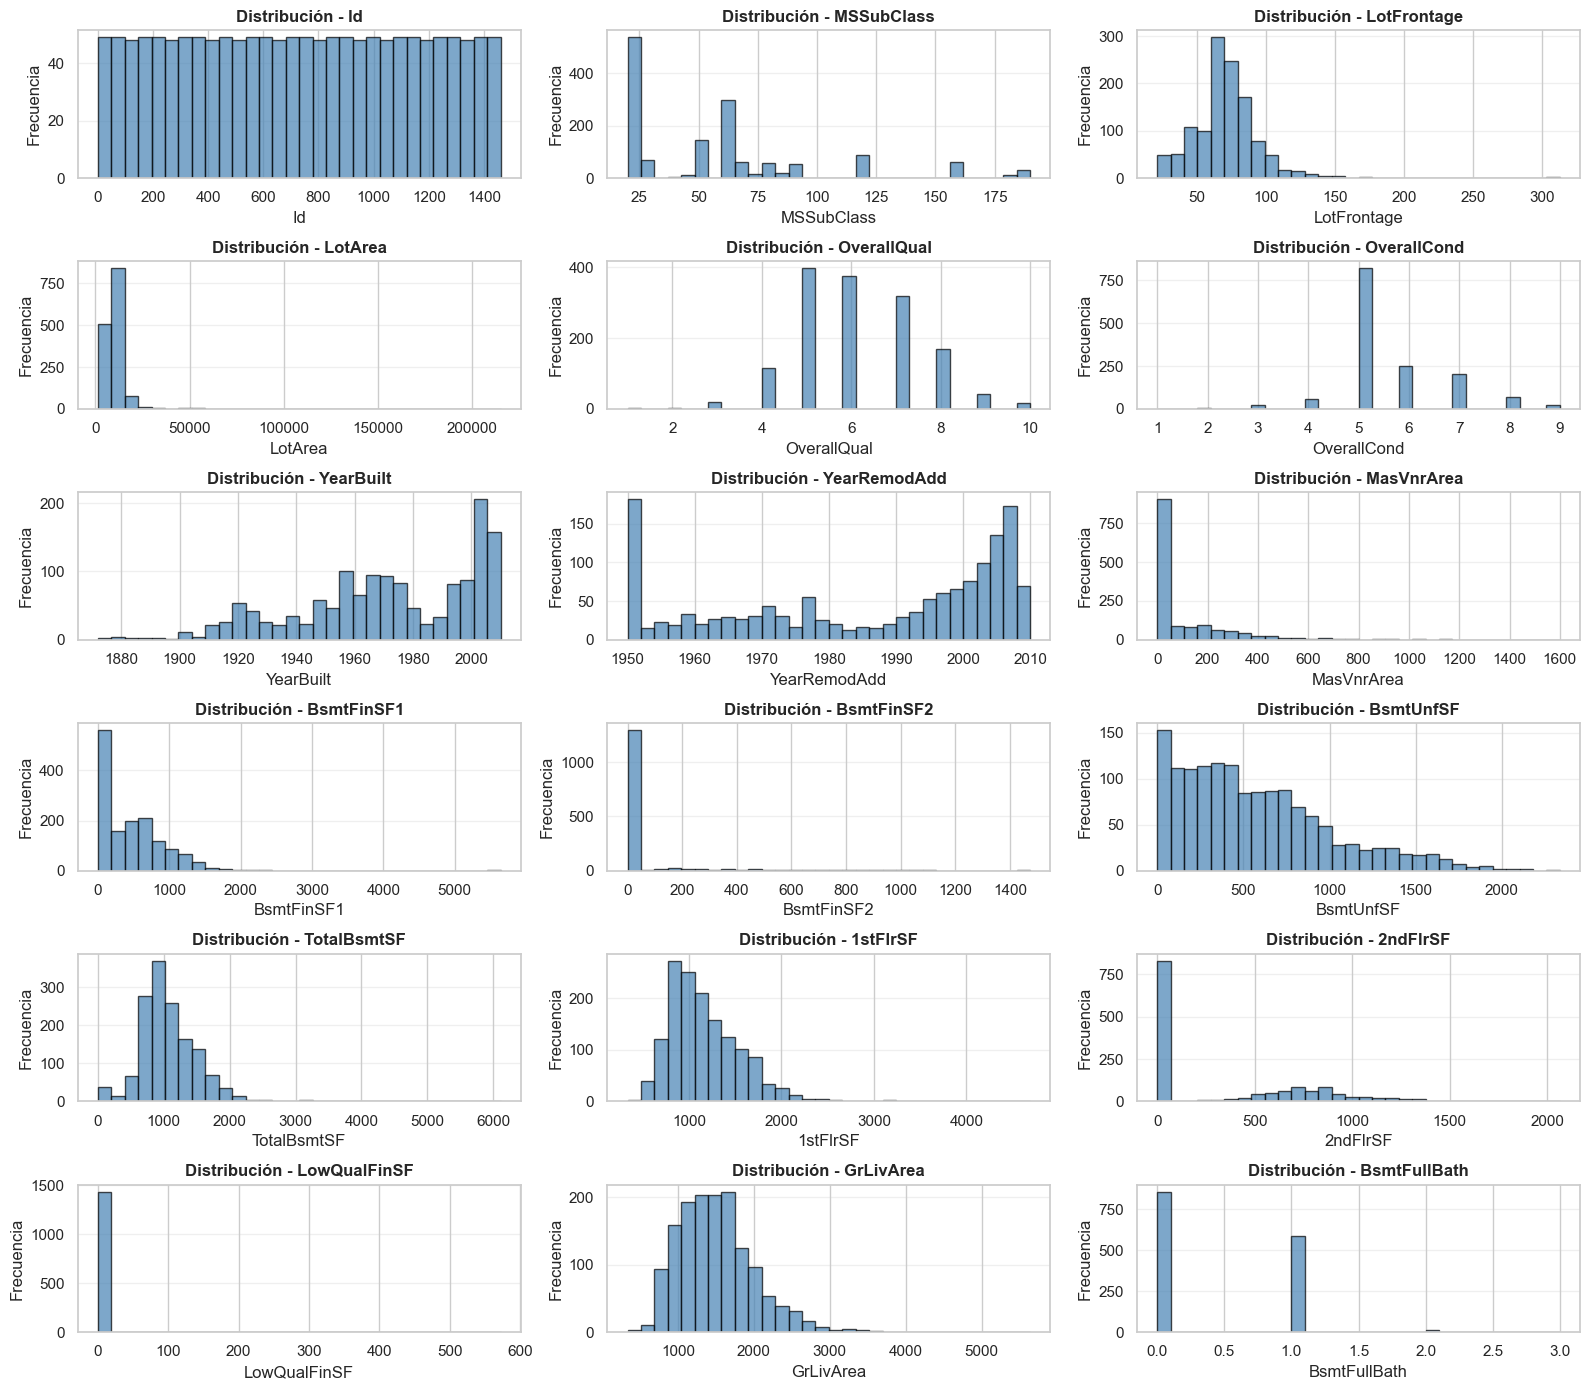

Histogramas de las primeras 18 variables numéricas


In [49]:
# Visualizar distribuciones de variables numéricas (primeras 15 variables)
fig, axes = plt.subplots(6, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:18]):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución - {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Histogramas de las primeras 18 variables numéricas")

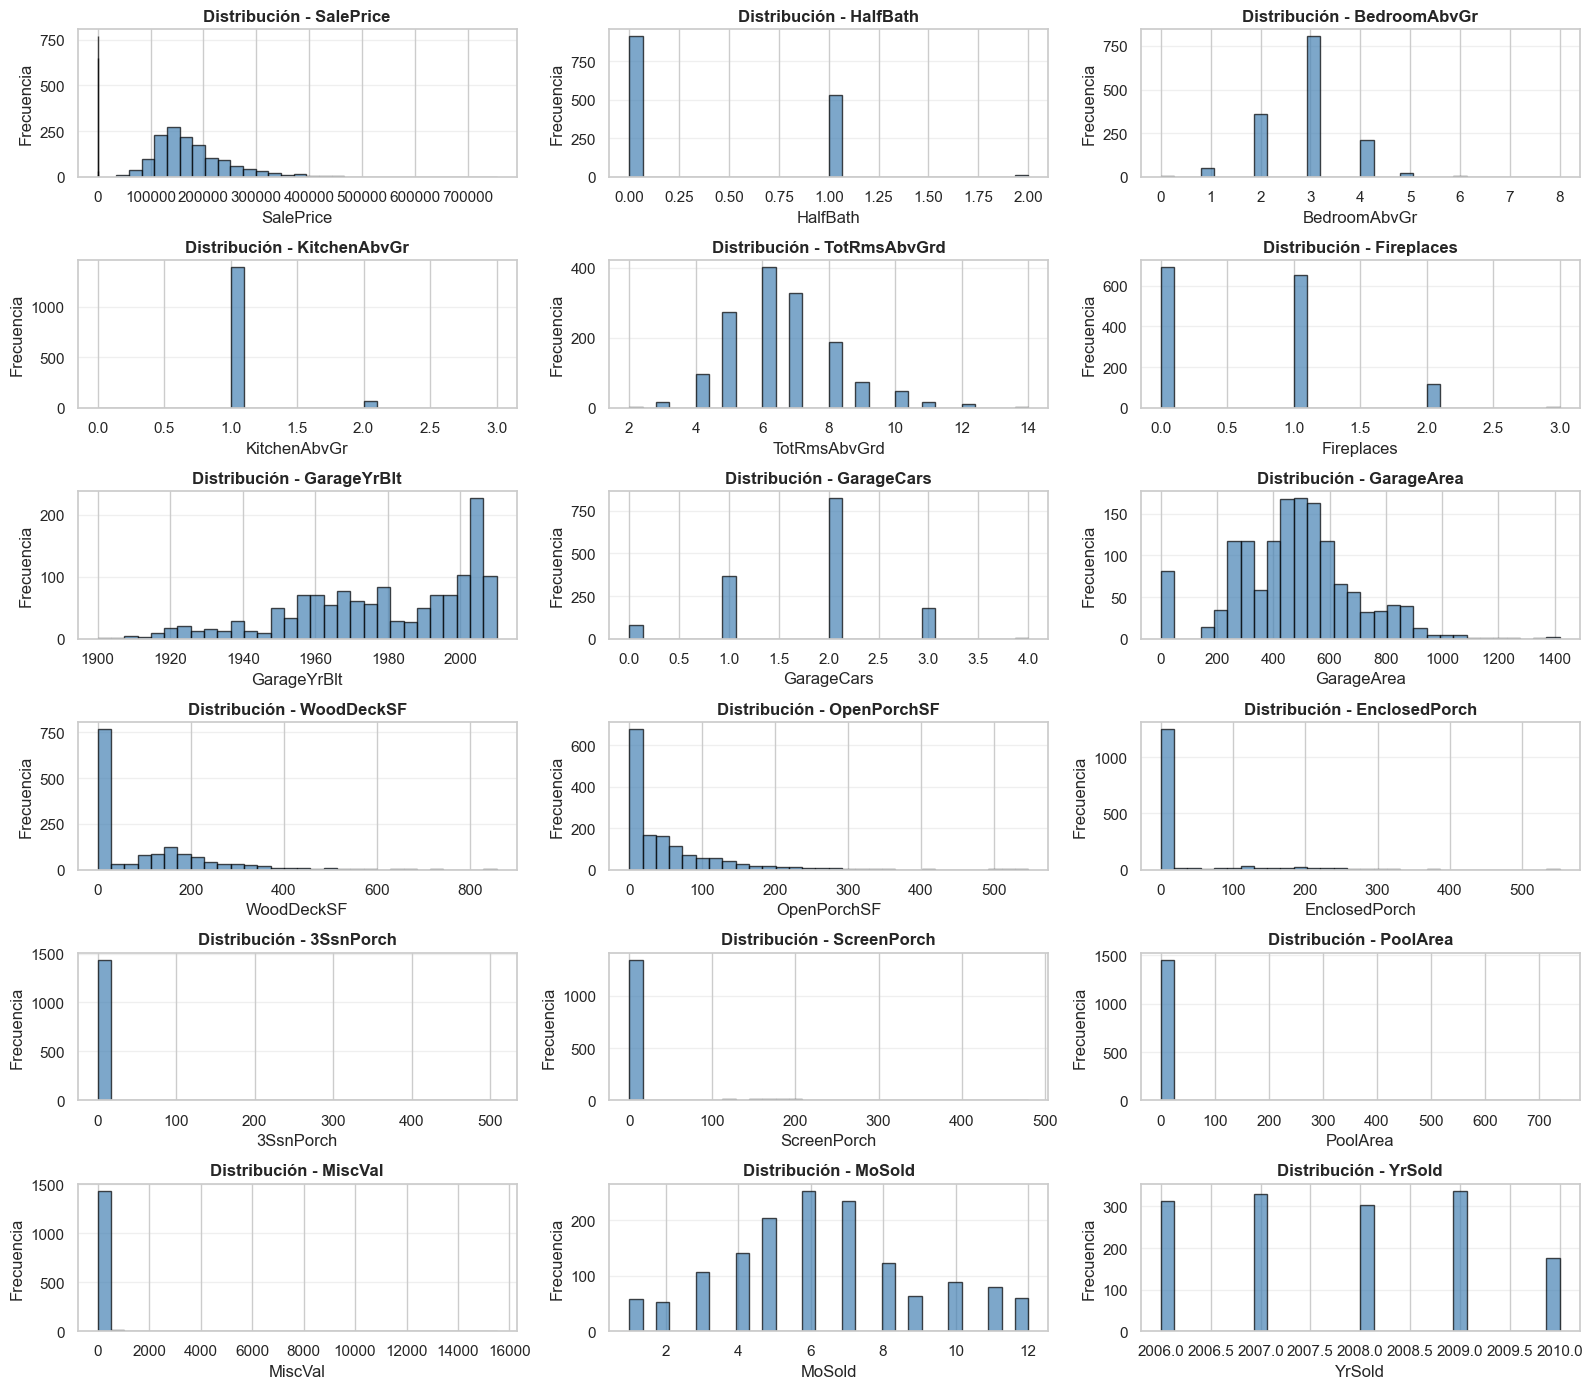

Histogramas de las otras 20 variables numéricas


In [50]:
# Visualizar distribuciones de variables numéricas (primeras 15 variables)
fig, axes = plt.subplots(6, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[19:38]):
    axes[idx-18].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx-18].set_title(f'Distribución - {col}', fontweight='bold')
    axes[idx-18].set_xlabel(col)
    axes[idx-18].set_ylabel('Frecuencia')
    axes[idx-18].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Histogramas de las otras 20 variables numéricas")

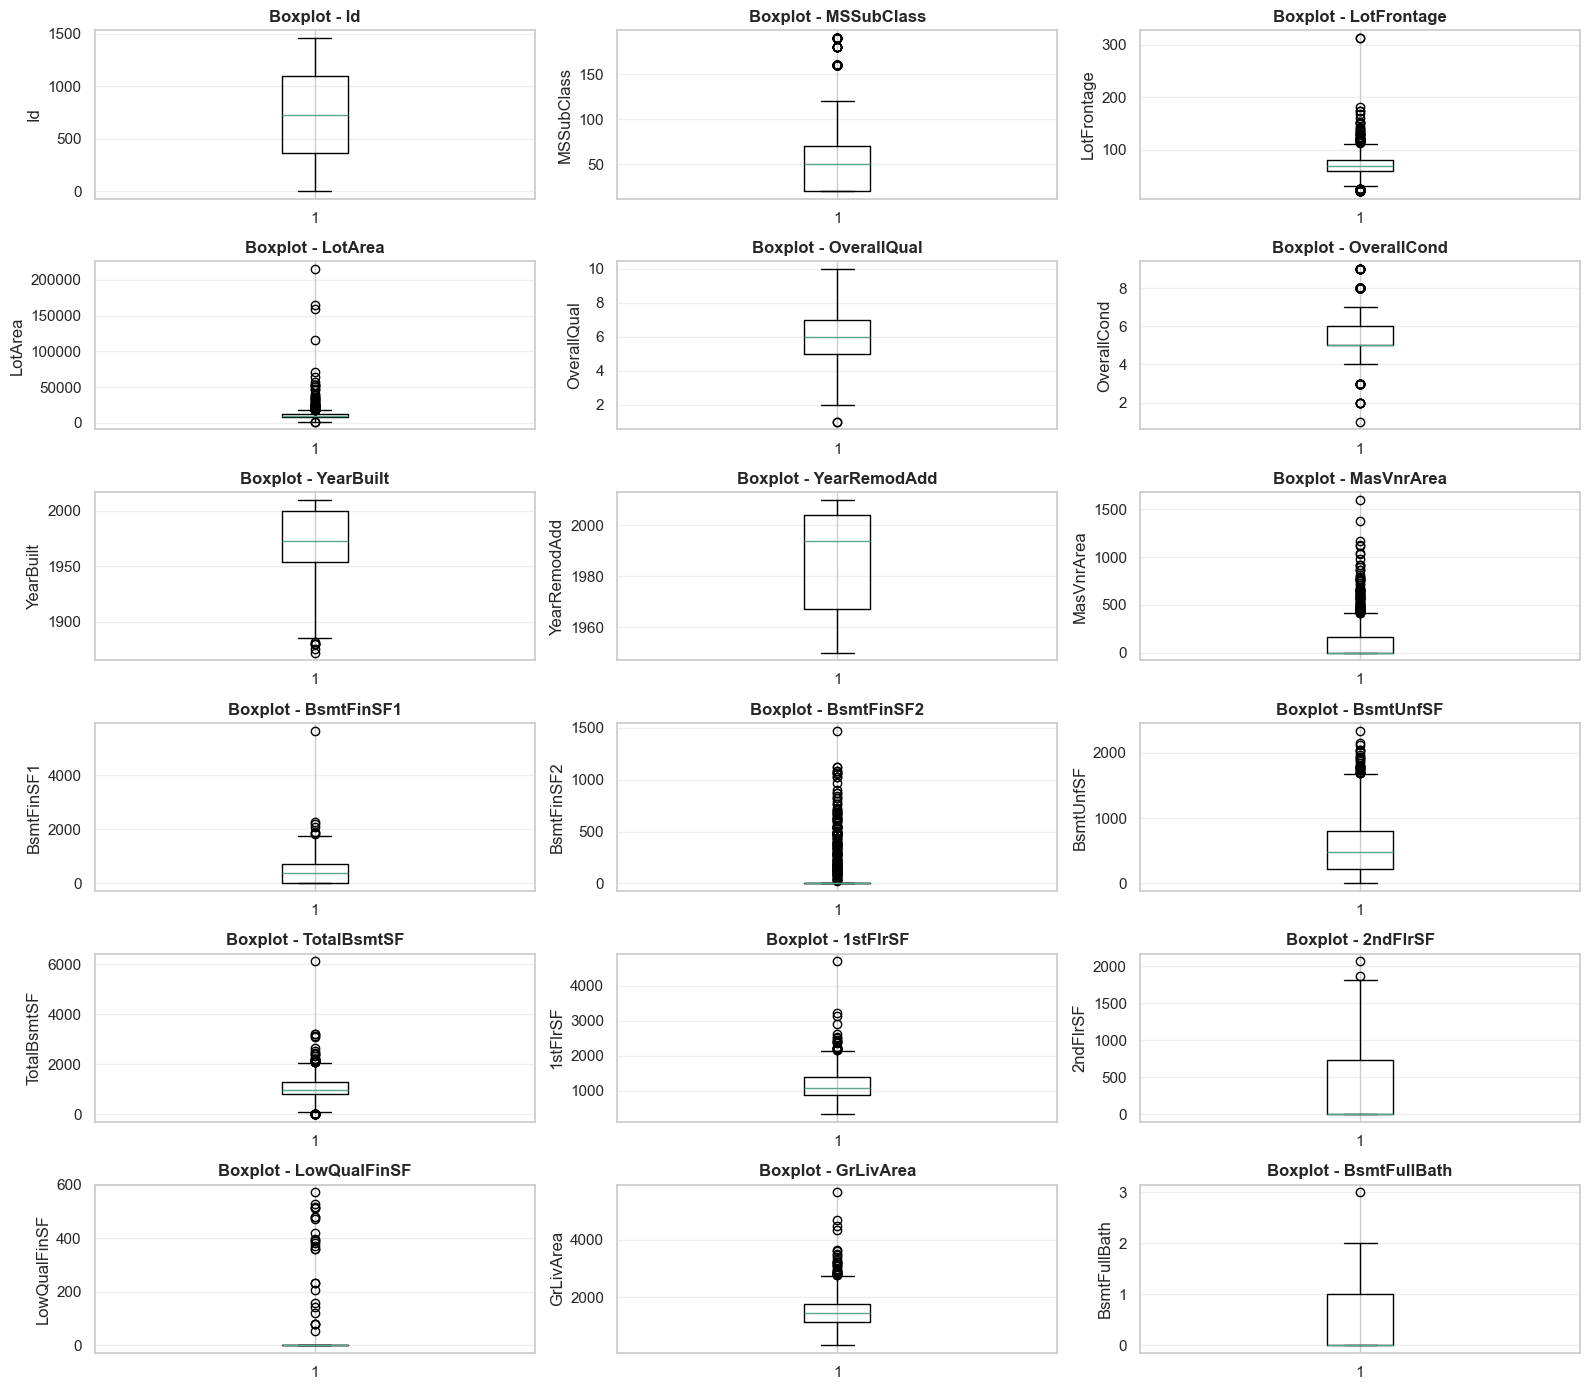

Boxplots de las primeras 18 variables numéricas (útiles para identificar outliers)


In [51]:
# Boxplots para detectar outliers en variables numéricas (primeras 18 variables)
fig, axes = plt.subplots(6, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:18]):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Boxplots de las primeras 18 variables numéricas (útiles para identificar outliers)")

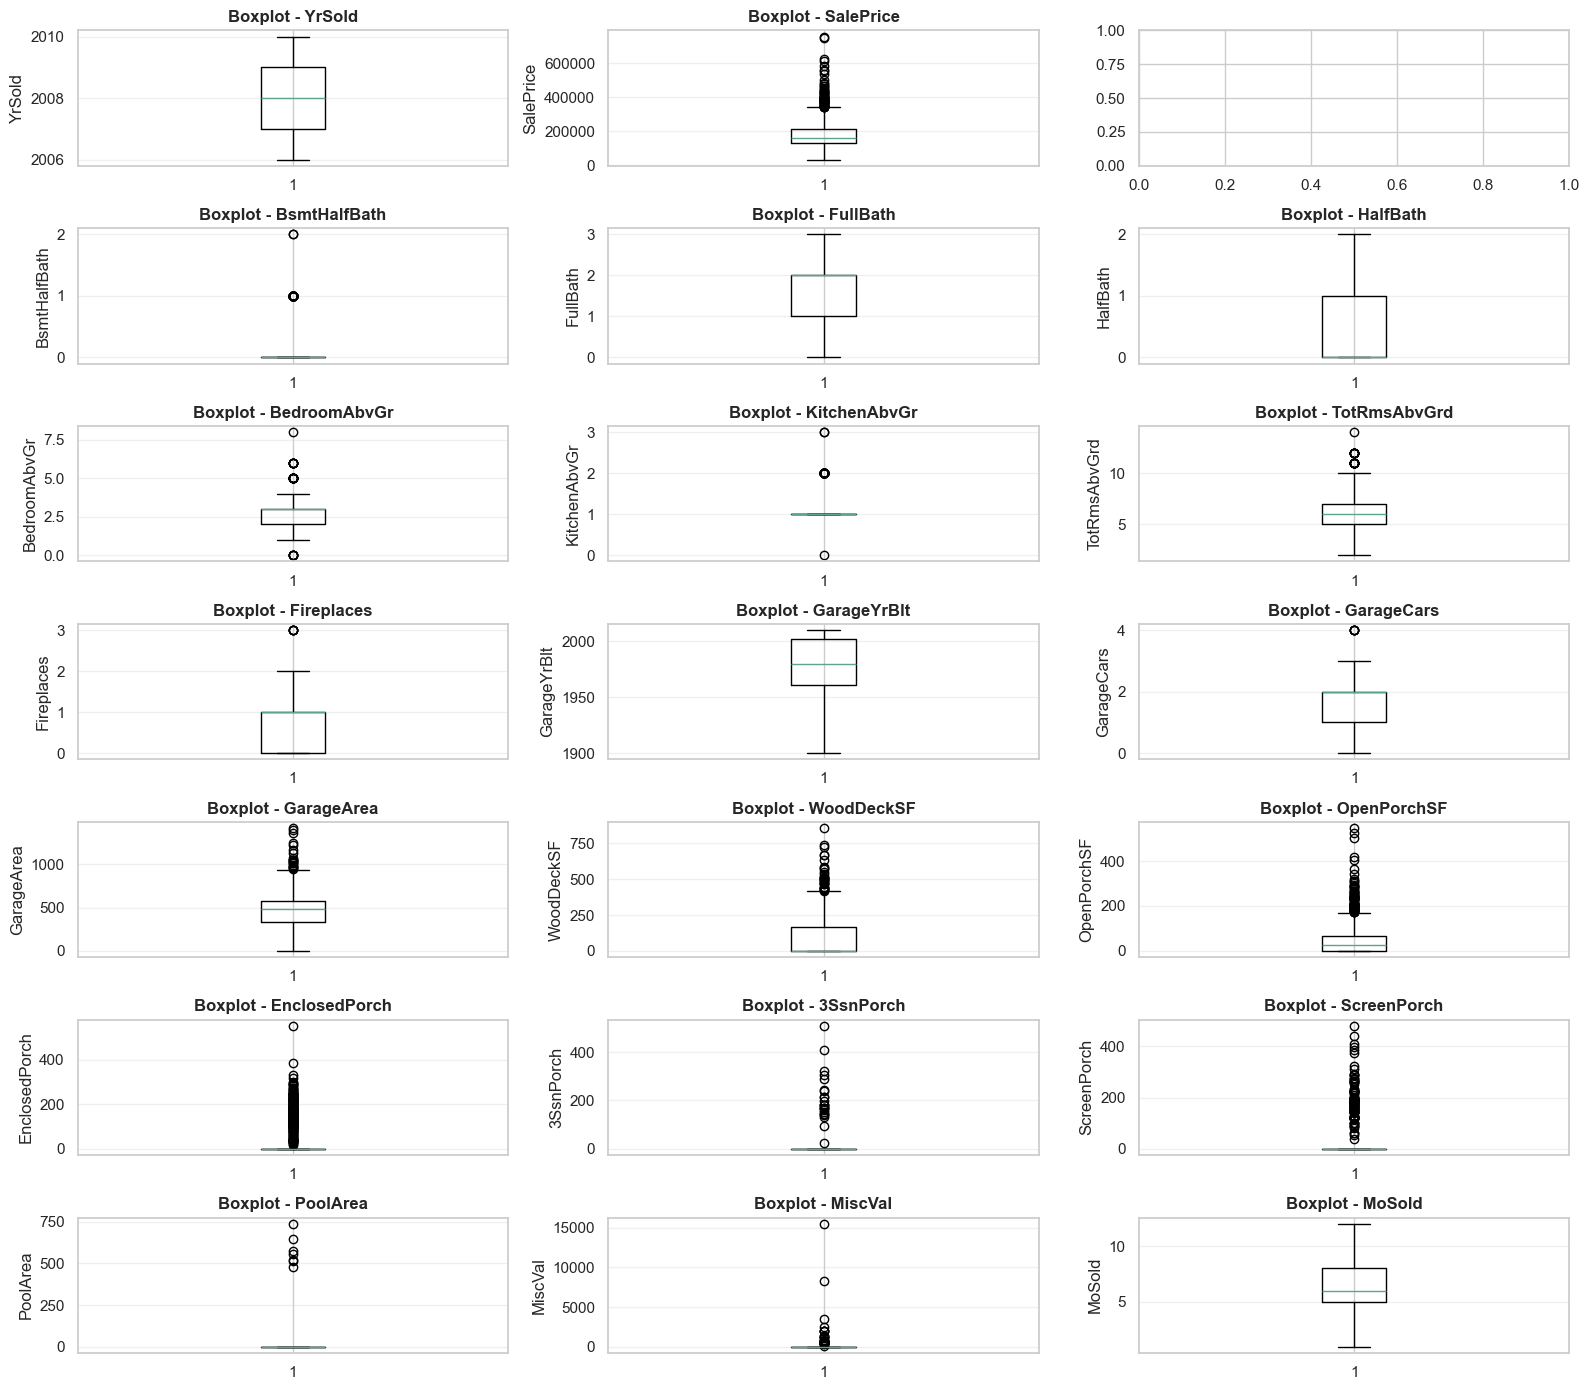

Boxplots de las otras 20 variables numéricas (útiles para identificar outliers)


In [52]:
# Boxplots para detectar outliers en variables numéricas (primeras 15 variables)
fig, axes = plt.subplots(7, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[18:38]):
    axes[idx-18].boxplot(df[col].dropna(), vert=True)
    axes[idx-18].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[idx-18].set_ylabel(col)
    axes[idx-18].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Boxplots de las otras 20 variables numéricas (útiles para identificar outliers)")

### 2.2 Variables categoricas

Frecuencia de categorias por variable para entender cardinalidad, dominancia de clases y categorias raras.

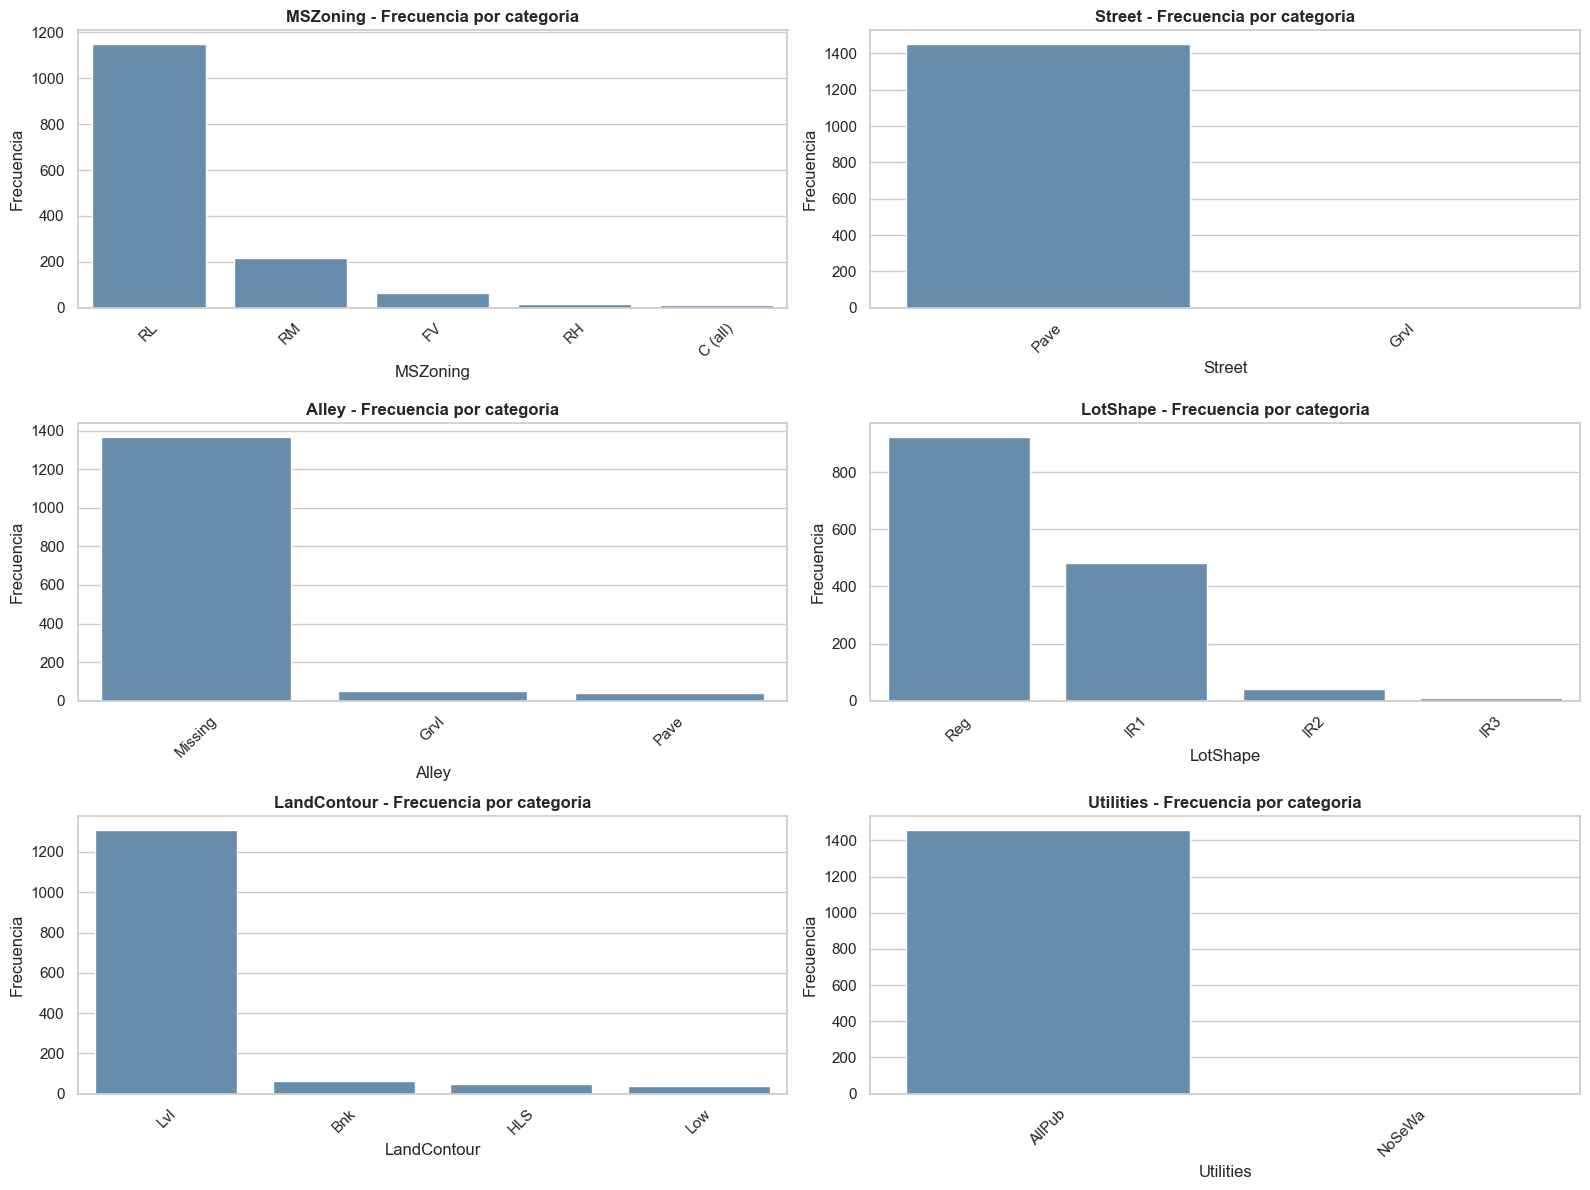

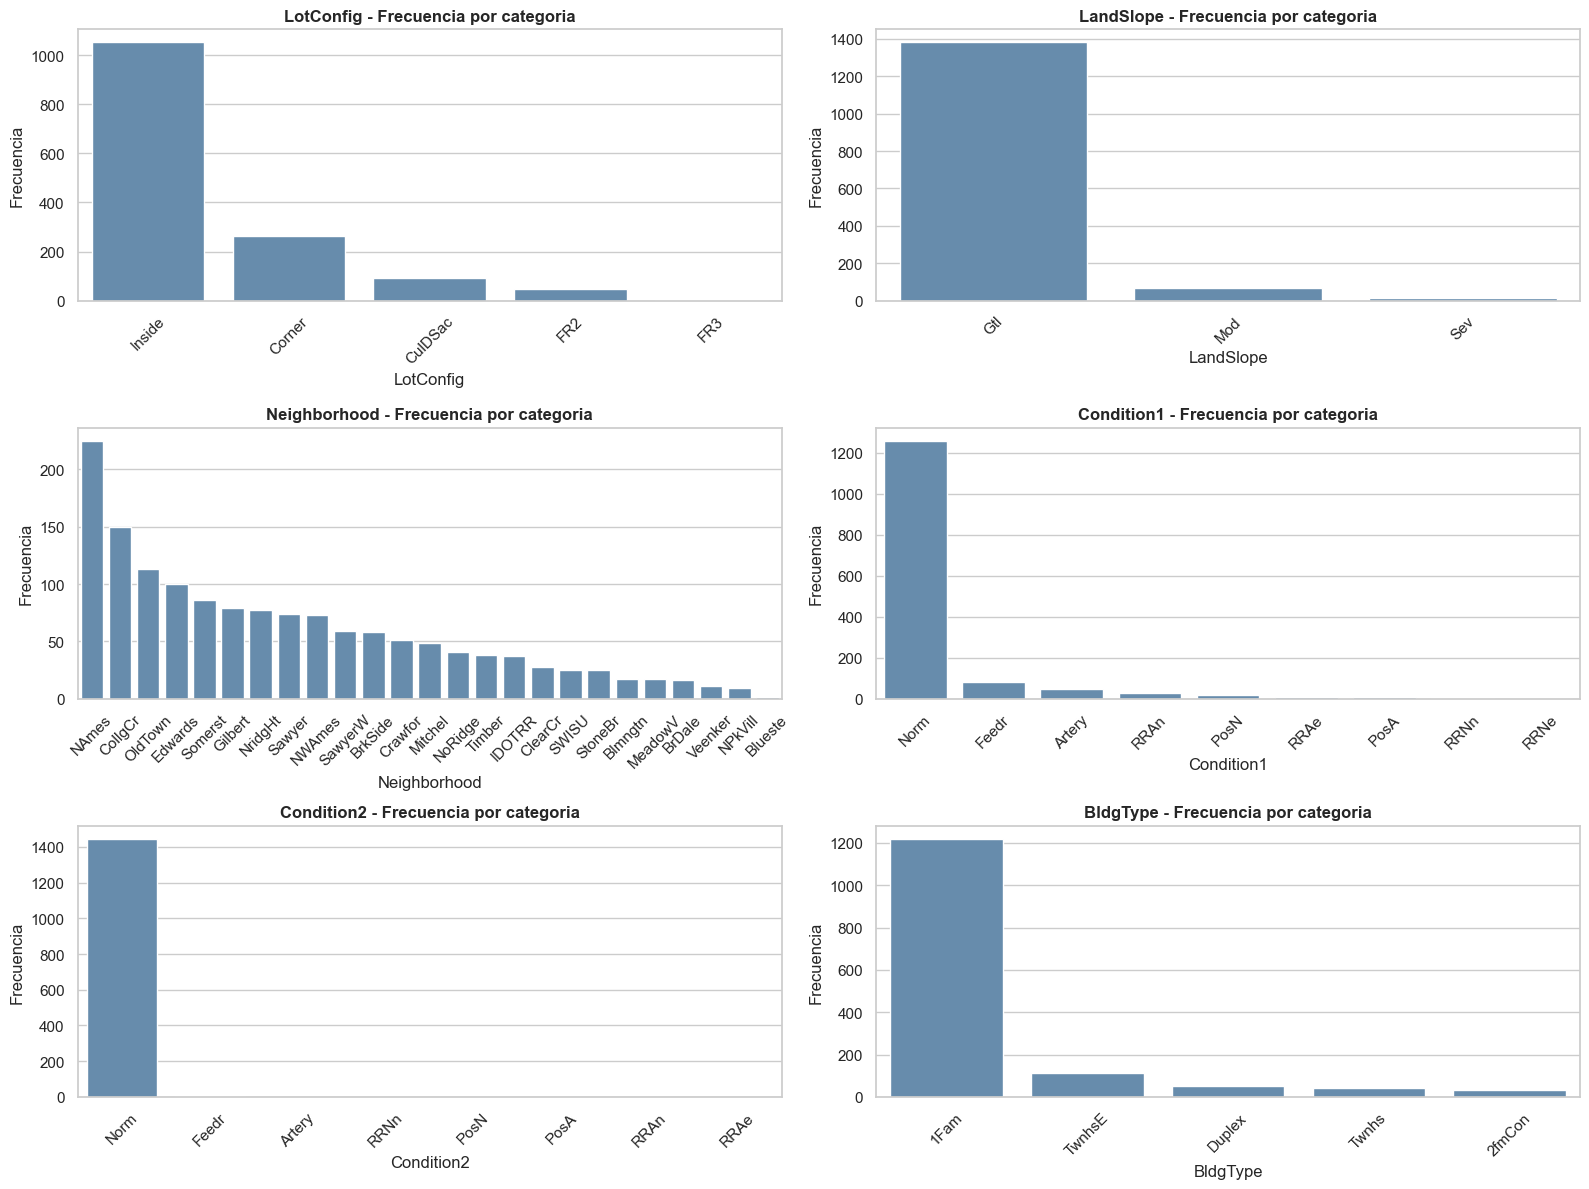

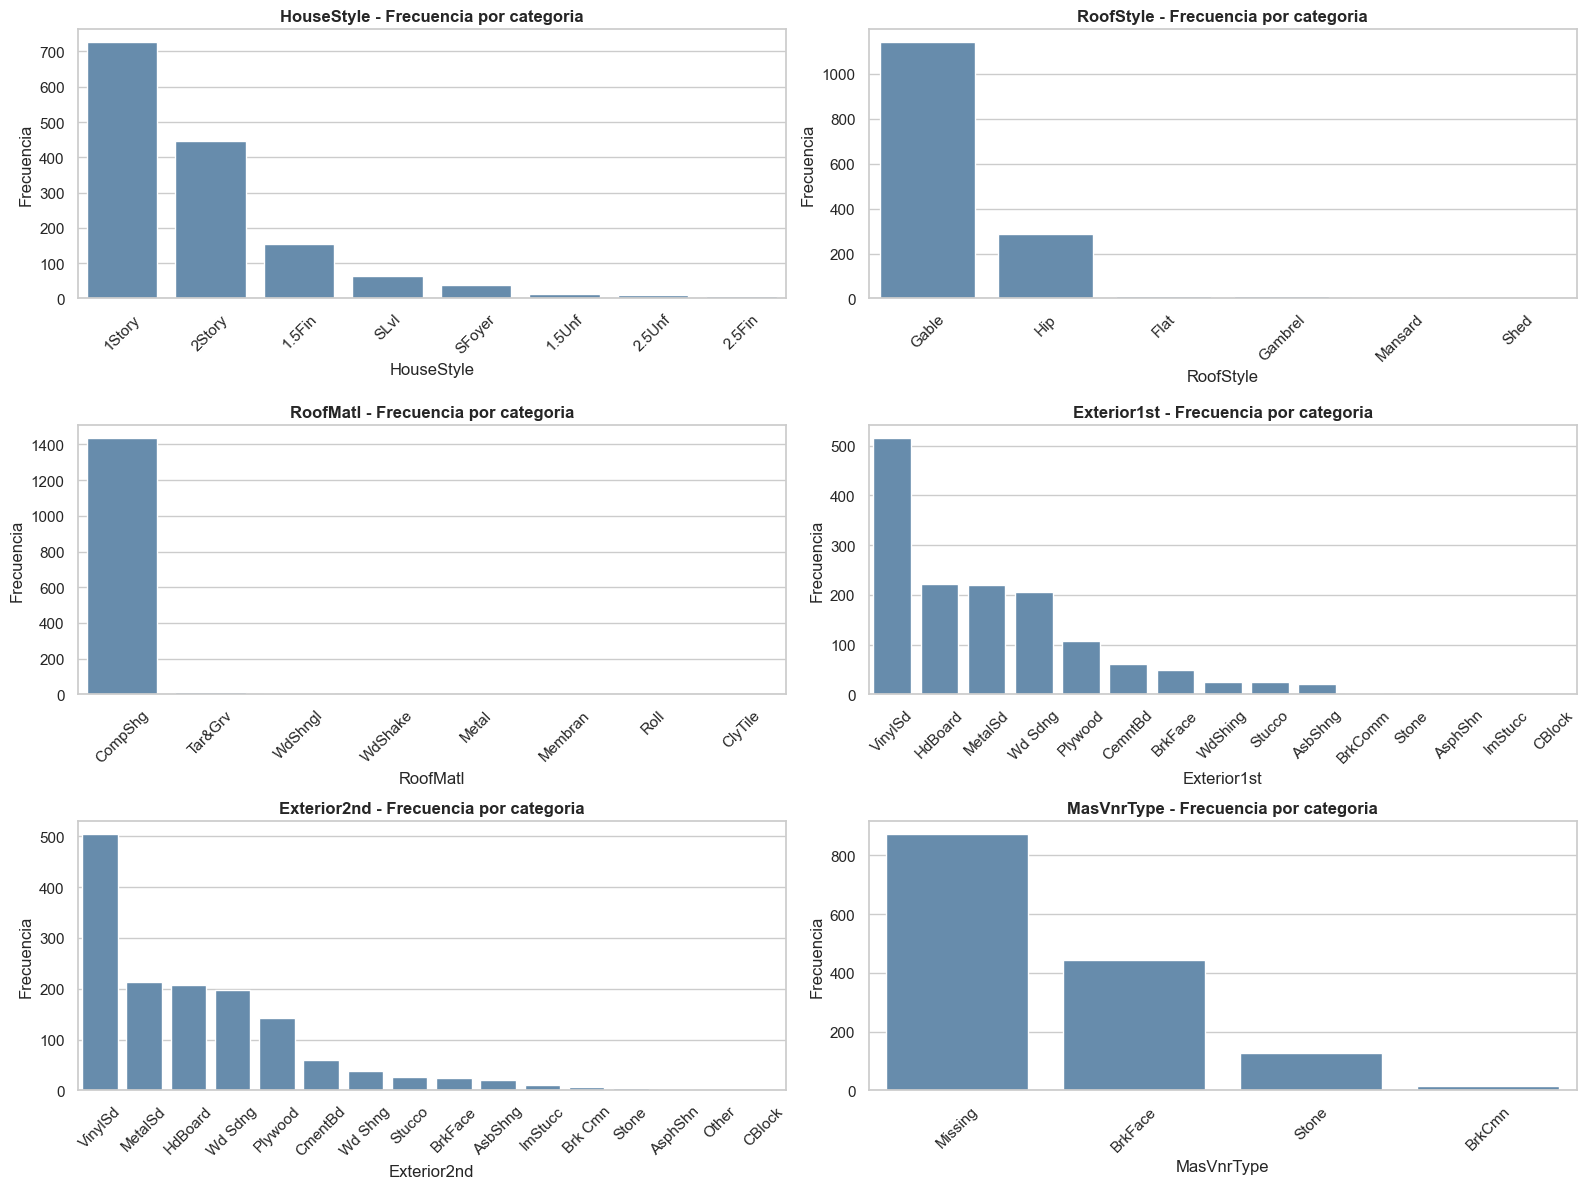

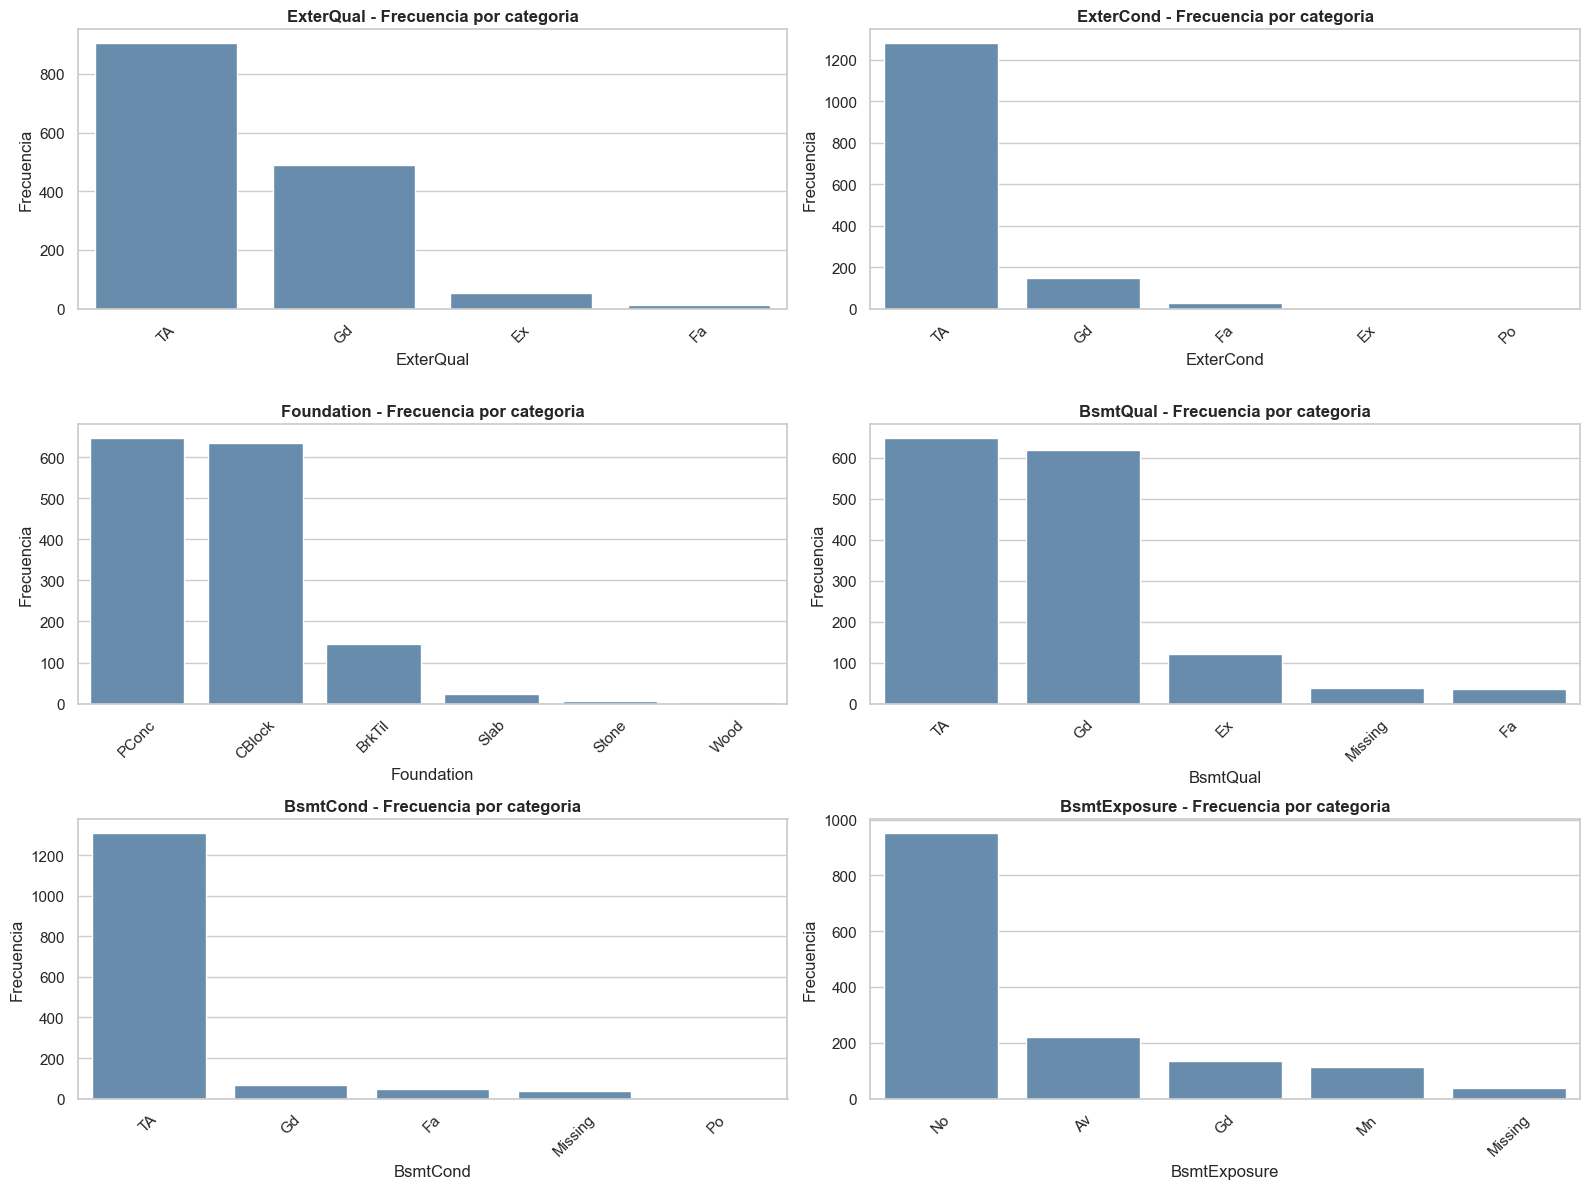

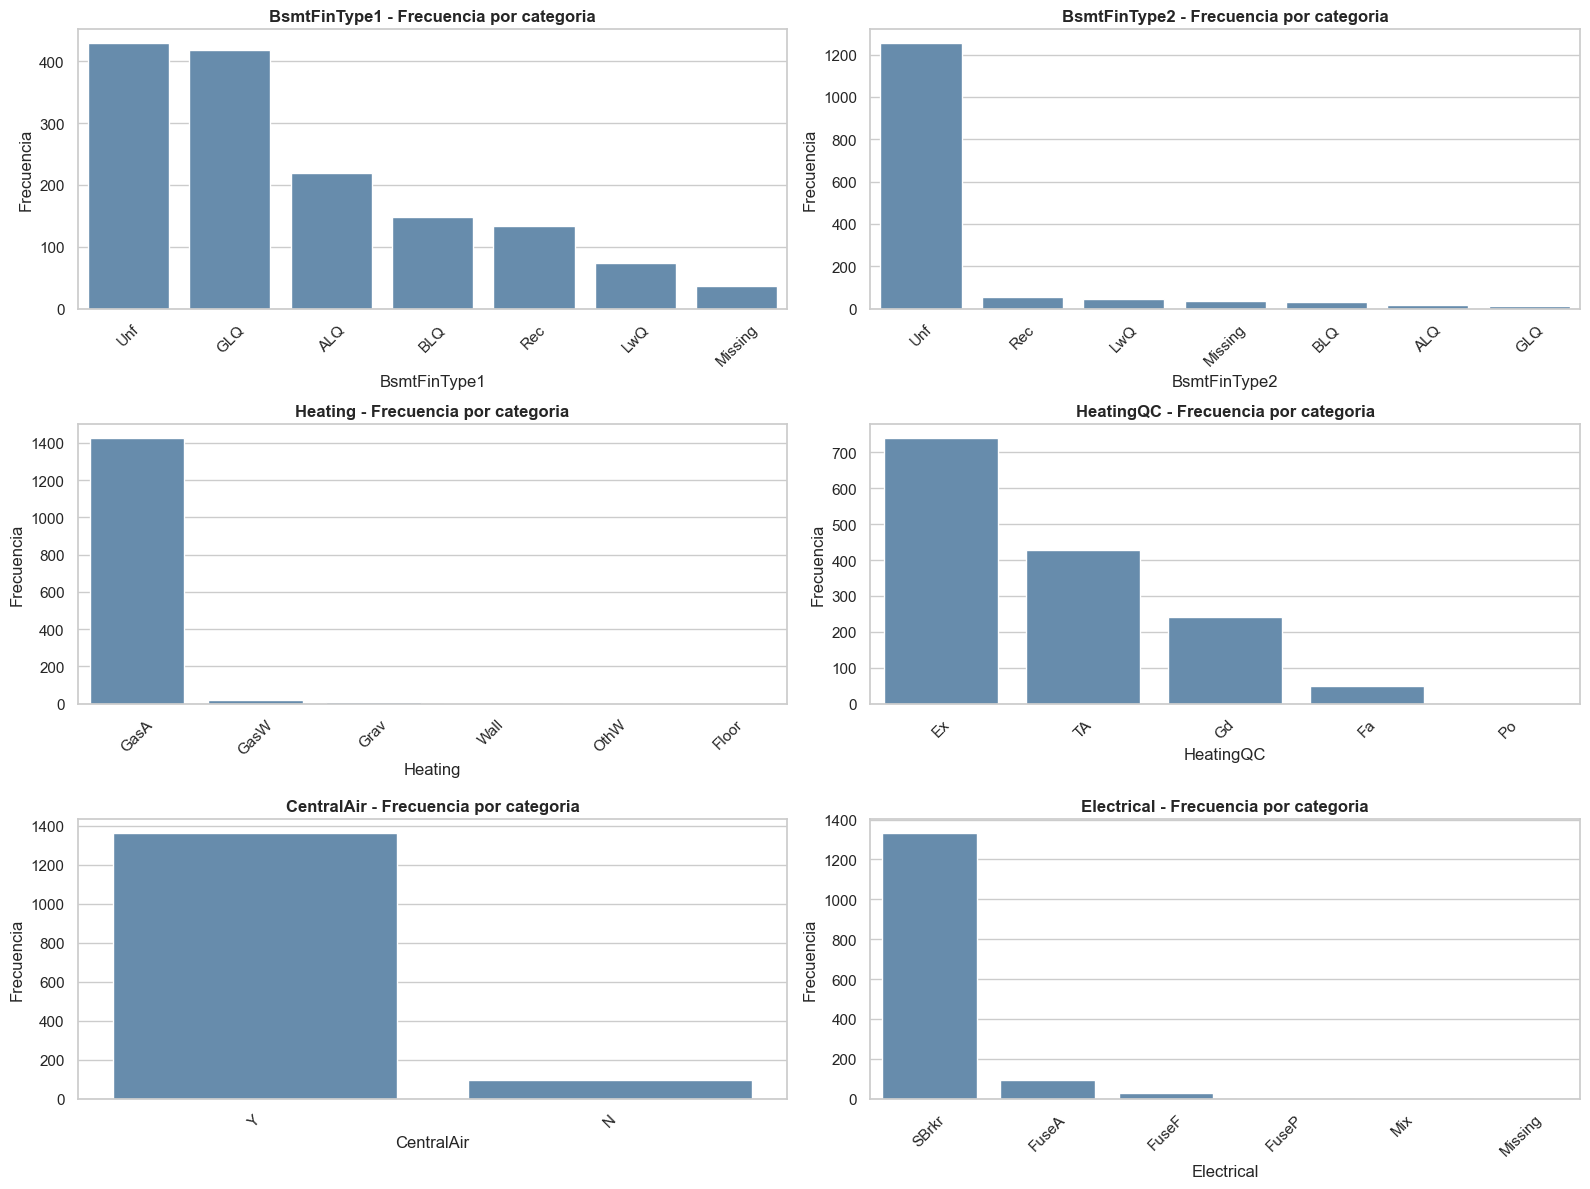

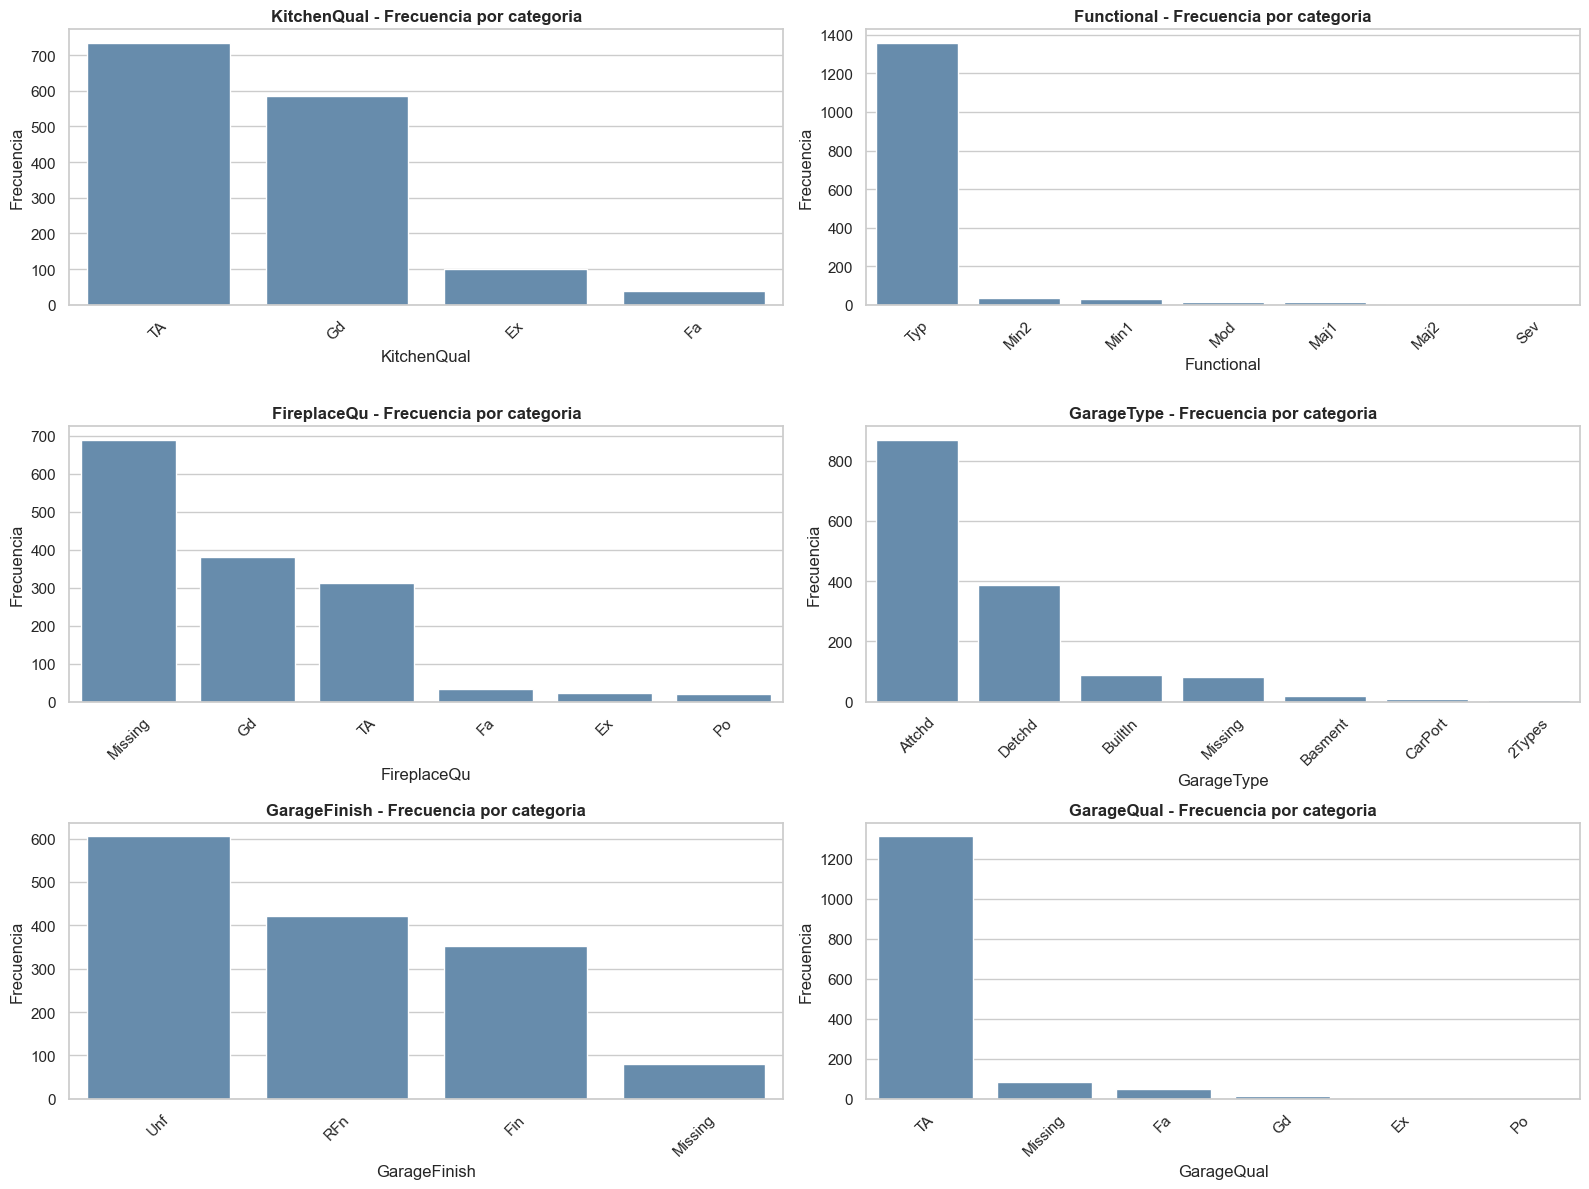

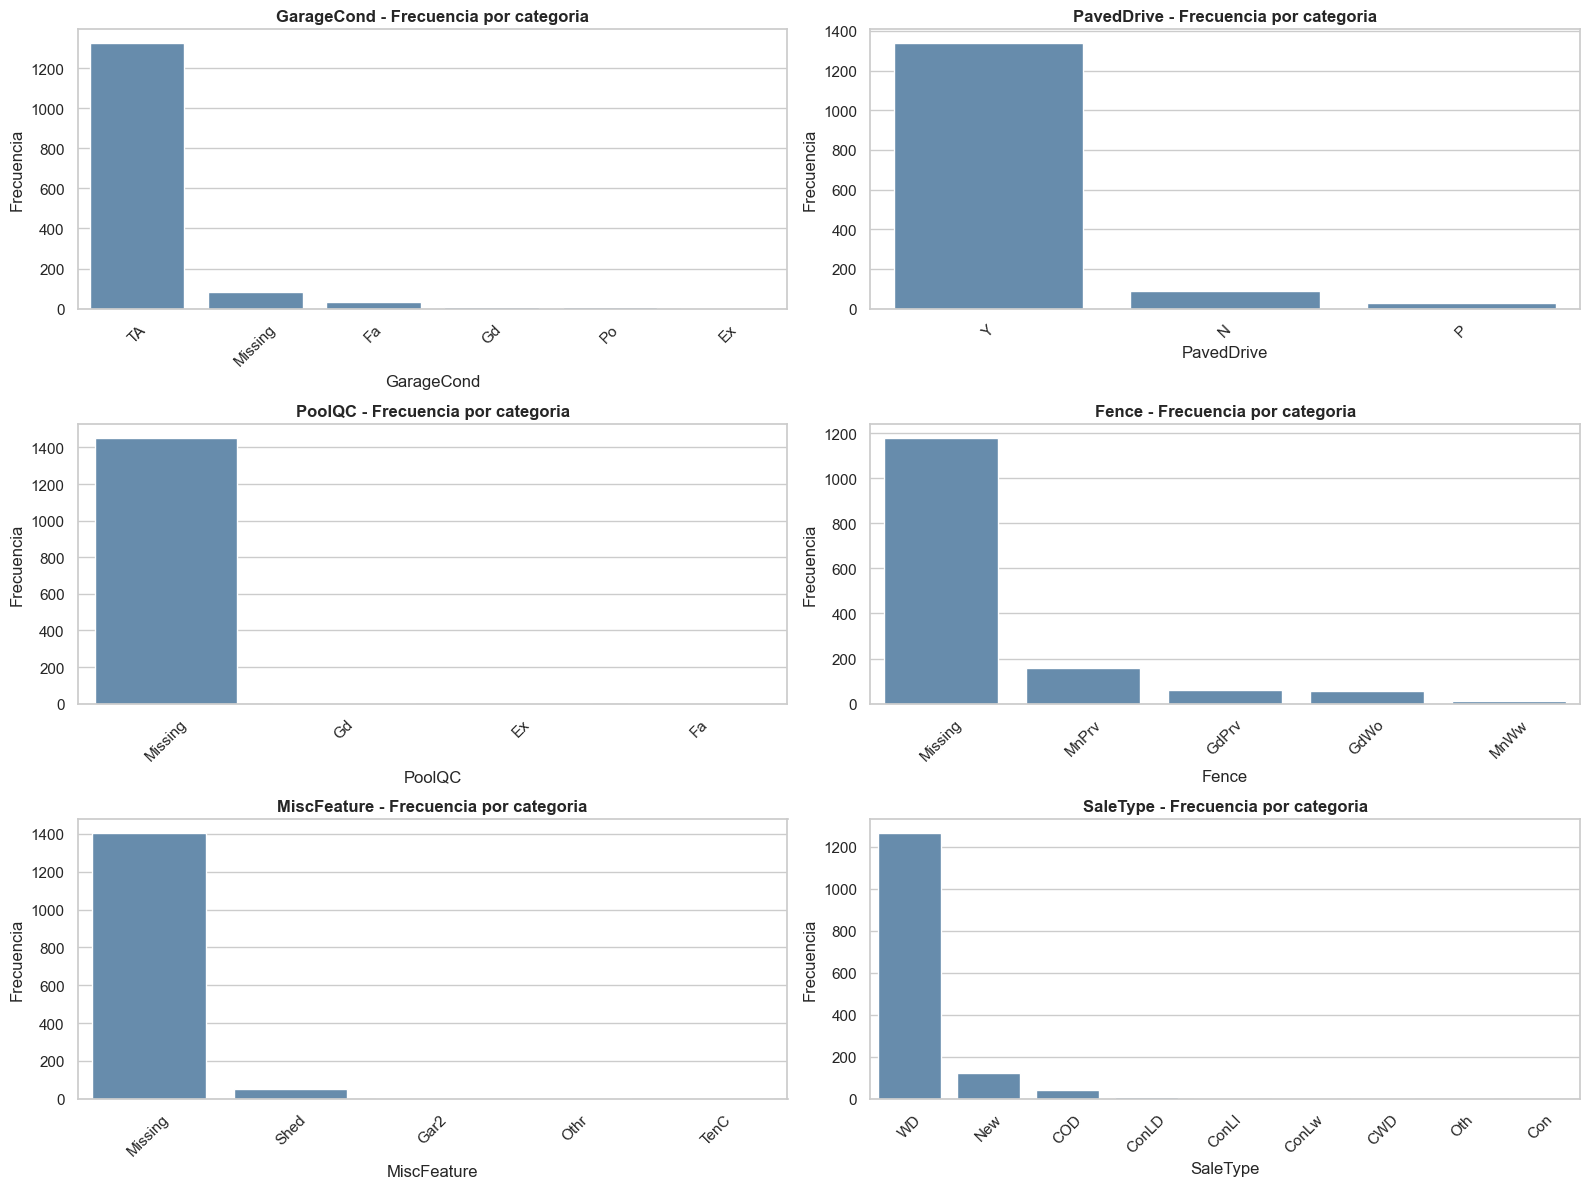

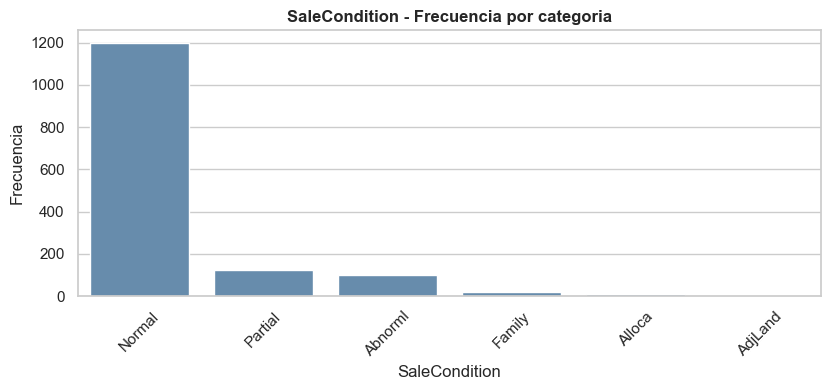

In [53]:
# Distribucion por categoria para cada variable categorica (en lotes para legibilidad)
batch_size = 6
for start in range(0, len(categorical_cols), batch_size):
    batch_cols = categorical_cols[start:start + batch_size]
    n = len(batch_cols)
    nrows = int(np.ceil(n / 2))

    fig, axes = plt.subplots(nrows, 2, figsize=(16, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(batch_cols):
        counts = df[col].fillna("Missing").value_counts(dropna=False)
        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[i], color="#5b8db8")
        axes[i].set_title(f"{col} - Frecuencia por categoria", fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frecuencia")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## 3. Deteccion de outliers

Analisis de outliers desde dos perspectivas complementarias: metodos estadisticos y validaciones logicas de consistencia.

### 3.1 Deteccion matematica (IQR y Z-score)

Top 20 variables con mayor porcentaje de outliers por IQR:


,variable,iqr_outliers,iqr_pct,zscore_outliers,zscore_pct
30,EnclosedPorch,208,14.246575,51,3.493151
10,BsmtFinSF2,167,11.438356,50,3.424658
5,OverallCond,125,8.561644,28,1.917808
32,ScreenPorch,116,7.945205,55,3.767123
2,LotFrontage,88,7.327227,12,0.999167
1,MSSubClass,103,7.054795,30,2.054795
8,MasVnrArea,96,6.611570,32,2.203857
18,BsmtHalfBath,82,5.616438,82,5.616438
29,OpenPorchSF,77,5.273973,27,1.849315
3,LotArea,69,4.726027,13,0.890411


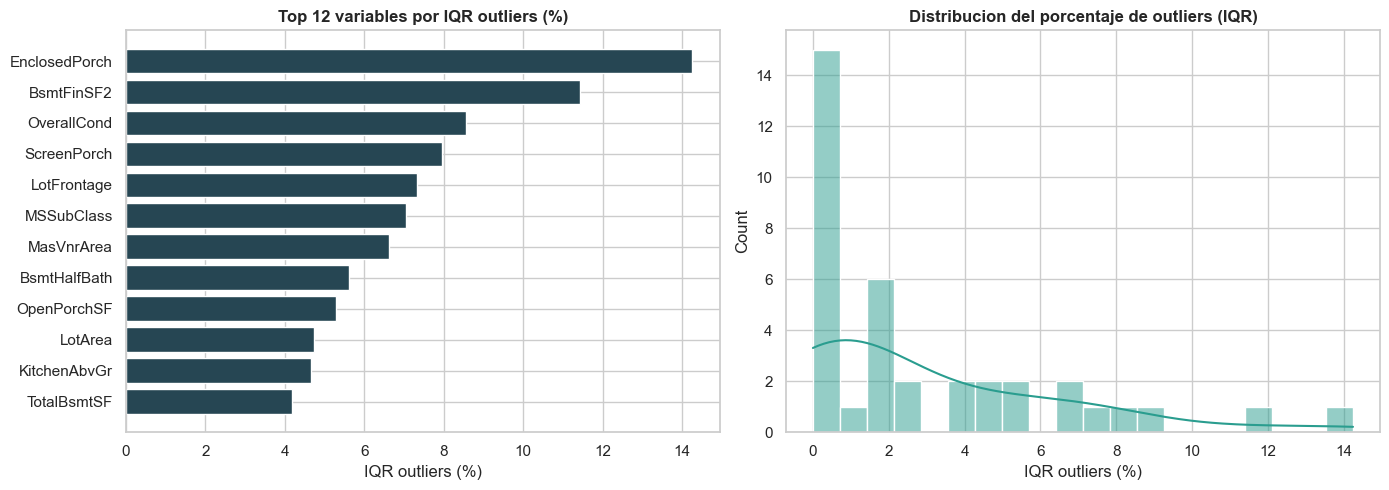

In [54]:
# 3.1 Outliers por IQR y Z-score
from scipy.stats import zscore

num_cols = [c for c in df.select_dtypes(include="number").columns if c != "SalePrice"]
outlier_rows = []

for col in num_cols:
    s = df[col].dropna()
    if s.empty:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    iqr_count = int(((s < lower_iqr) | (s > upper_iqr)).sum())

    if s.std(ddof=0) > 0:
        z_count = int((np.abs(zscore(s, nan_policy="omit")) > 3).sum())
    else:
        z_count = 0

    outlier_rows.append(
        {
            "variable": col,
            "iqr_outliers": iqr_count,
            "iqr_pct": (iqr_count / len(s)) * 100,
            "zscore_outliers": z_count,
            "zscore_pct": (z_count / len(s)) * 100,
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("iqr_pct", ascending=False)
print("Top 20 variables con mayor porcentaje de outliers por IQR:")
display(outlier_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = outlier_summary.head(12).sort_values("iqr_pct", ascending=True)
axes[0].barh(plot_df["variable"], plot_df["iqr_pct"], color="#264653")
axes[0].set_title("Top 12 variables por IQR outliers (%)", fontweight="bold")
axes[0].set_xlabel("IQR outliers (%)")

sns.histplot(outlier_summary["iqr_pct"], bins=20, kde=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Distribucion del porcentaje de outliers (IQR)", fontweight="bold")
axes[1].set_xlabel("IQR outliers (%)")

plt.tight_layout()
plt.show()

### 3.2 Deteccion logica (reglas de negocio)

In [62]:
# 3.2 Pruebas logicas de outliers e inconsistencias
logical_checks = {}

# No casas construidas en el futuro
if "YearBuilt" in df.columns:
    logical_checks["yearbuilt_in_future"] = int((df["YearBuilt"] > pd.Timestamp.now().year).sum())

# No ventas antes de construccion
if {"YrSold", "YearBuilt"}.issubset(df.columns):
    logical_checks["sold_before_built"] = int((df["YrSold"] < df["YearBuilt"]).sum())

# Valores no validos basicos
for col in ["SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF", "GarageArea"]:
    if col in df.columns:
        logical_checks[f"{col}_non_positive"] = int((df[col] < 0).sum())

# Coherencia de remodelacion
if {"YearRemodAdd", "YearBuilt"}.issubset(df.columns):
    logical_checks["remodel_before_build"] = int((df["YearRemodAdd"] < df["YearBuilt"]).sum())

logical_checks_df = pd.DataFrame(
    {"check": list(logical_checks.keys()), "count": list(logical_checks.values())}
).sort_values("count", ascending=False)

print("Resultados de pruebas logicas de consistencia:")
display(logical_checks_df)

Resultados de pruebas logicas de consistencia:


,check,count
0,yearbuilt_in_future,0
1,sold_before_built,0
2,SalePrice_non_positive,0
3,GrLivArea_non_positive,0
4,LotArea_non_positive,0
5,TotalBsmtSF_non_positive,0
6,GarageArea_non_positive,0
7,remodel_before_build,0


## 4. Analisis de correlaciones con la variable objetivo

Esta seccion conecta la variable objetivo con las variables explicativas mediante resumen, correlacion y dispersion.

### 4.1 Descripcion de la variable objetivo (`SalePrice`)

DESCRIPCION DE LA VARIABLE OBJETIVO: SalePrice
Media: $180,921.20
Mediana: $163,000.00
Desviacion estandar: $79,442.50
Rango: $34,900.00 - $755,000.00
Asimetria: 1.881


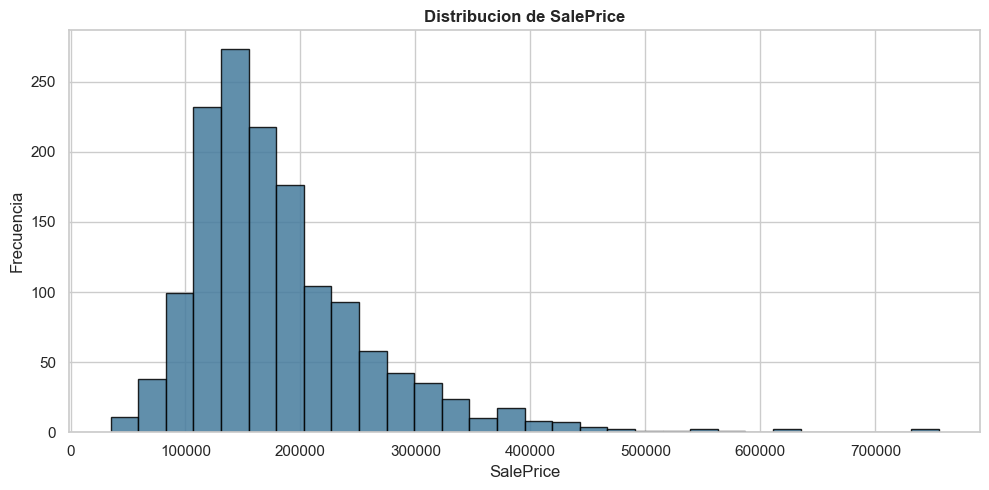

In [56]:
# 4.1 Descripcion de SalePrice
print("=" * 80)
print("DESCRIPCION DE LA VARIABLE OBJETIVO: SalePrice")
print("=" * 80)

target_col = "SalePrice"

mean_price = df[target_col].mean()
median_price = df[target_col].median()
std_price = df[target_col].std()
min_price = df[target_col].min()
max_price = df[target_col].max()
skewness = stats.skew(df[target_col].dropna())

print(f"Media: ${mean_price:,.2f}")
print(f"Mediana: ${median_price:,.2f}")
print(f"Desviacion estandar: ${std_price:,.2f}")
print(f"Rango: ${min_price:,.2f} - ${max_price:,.2f}")
print(f"Asimetria: {skewness:.3f}")

plt.figure(figsize=(10, 5))
plt.hist(df[target_col], bins=30, color="#457b9d", edgecolor="black", alpha=0.85)
plt.title("Distribucion de SalePrice", fontweight="bold")
plt.xlabel("SalePrice")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### 4.2 Matriz de correlacion

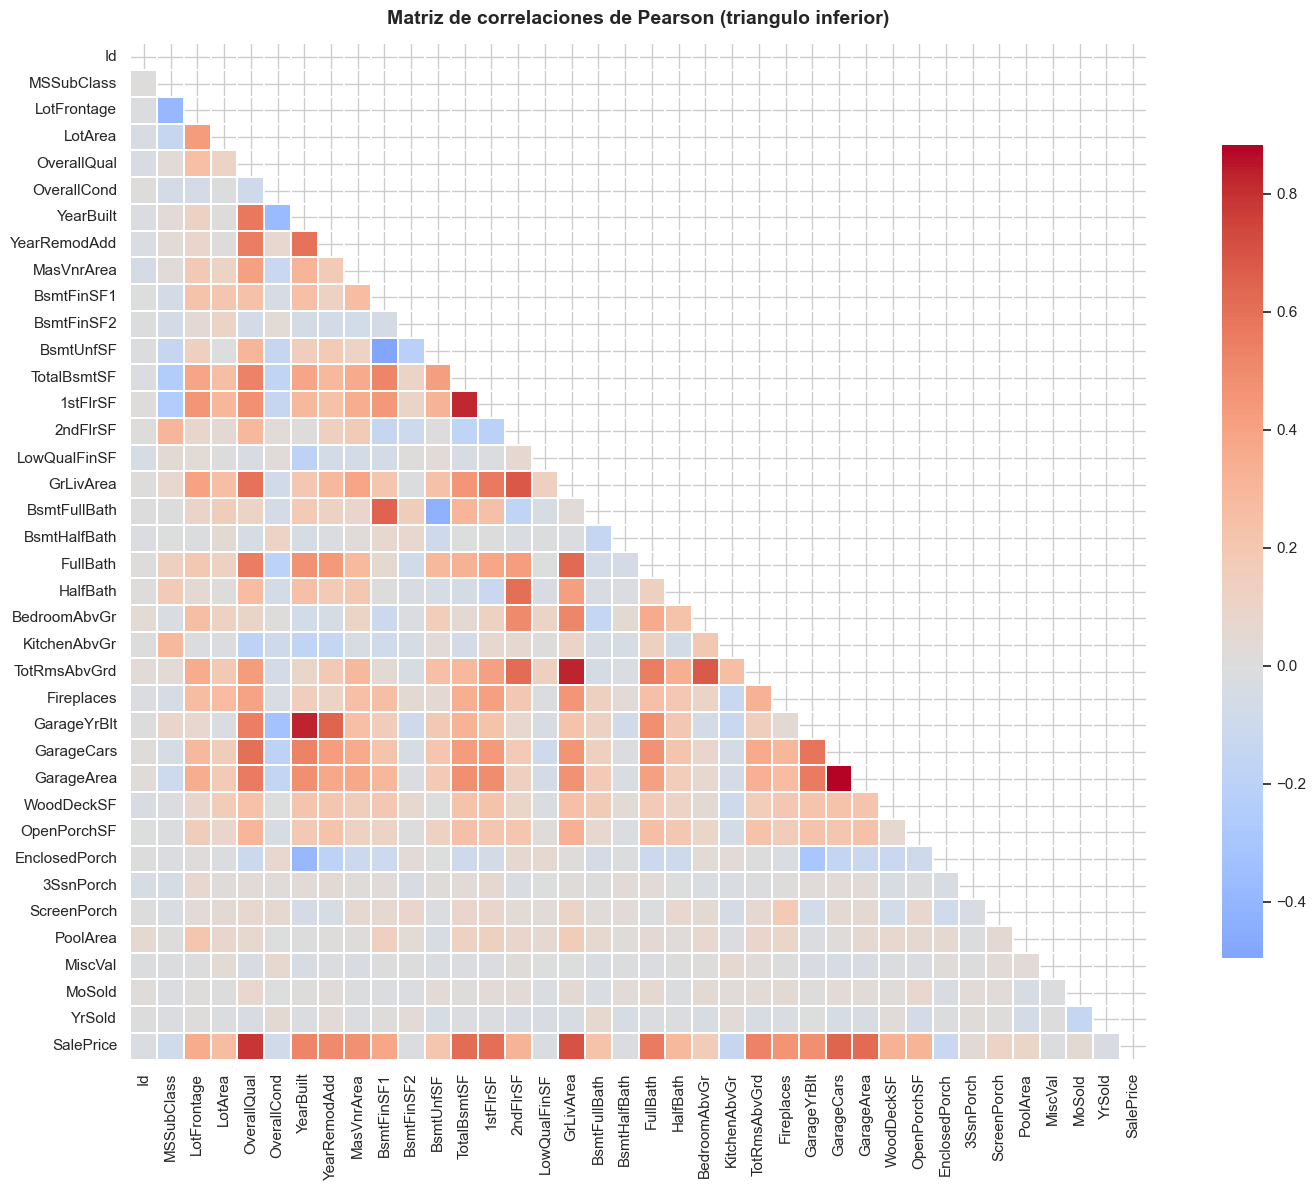

In [57]:
# 4.2 Matriz de correlacion
correlation_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matriz de correlaciones de Pearson (triangulo inferior)", fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

### 4.3 Correlaciones de Pearson con `SalePrice`

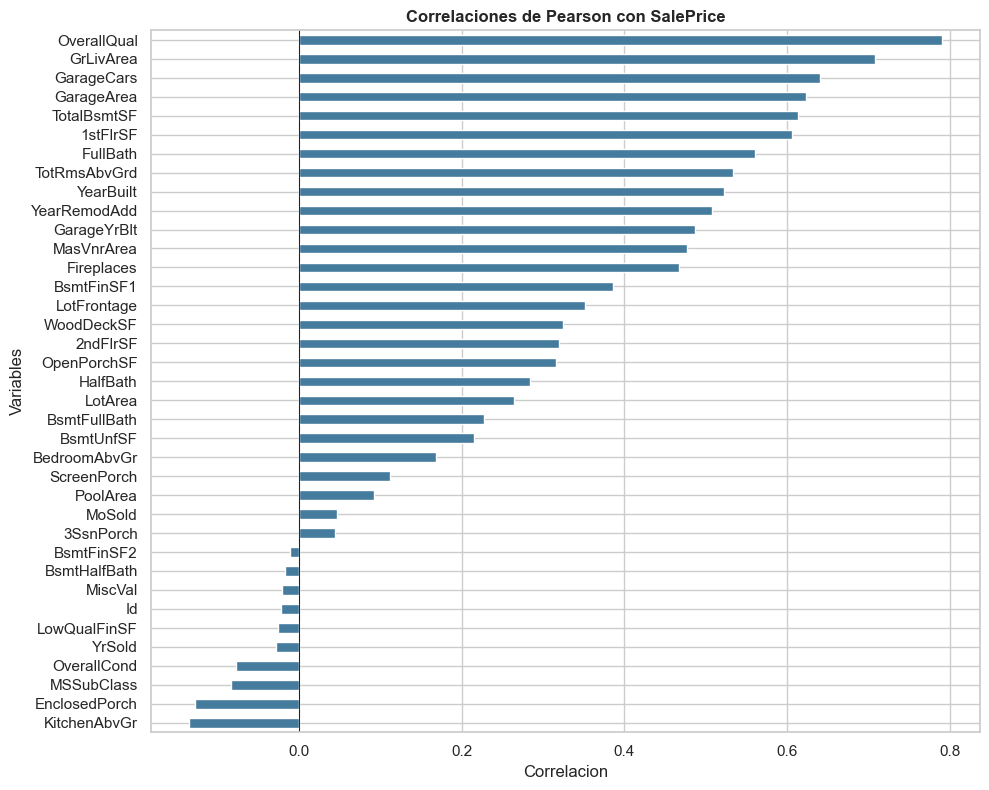

Top 10 correlaciones absolutas con SalePrice:


,abs_corr
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


In [58]:
# 4.3 Correlaciones de Pearson con SalePrice
correlations_with_target = correlation_matrix[target_col].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlations_with_target.drop(target_col).sort_values().plot(kind="barh", color="#457b9d")
plt.title("Correlaciones de Pearson con SalePrice", fontsize=12, fontweight="bold")
plt.xlabel("Correlacion")
plt.ylabel("Variables")
plt.axvline(x=0, color="black", linestyle="-", linewidth=0.6)
plt.tight_layout()
plt.show()

print("Top 10 correlaciones absolutas con SalePrice:")
display(correlations_with_target.drop(target_col).abs().sort_values(ascending=False).head(10).to_frame("abs_corr"))

### 4.4 Variables independientes vs variable dependiente

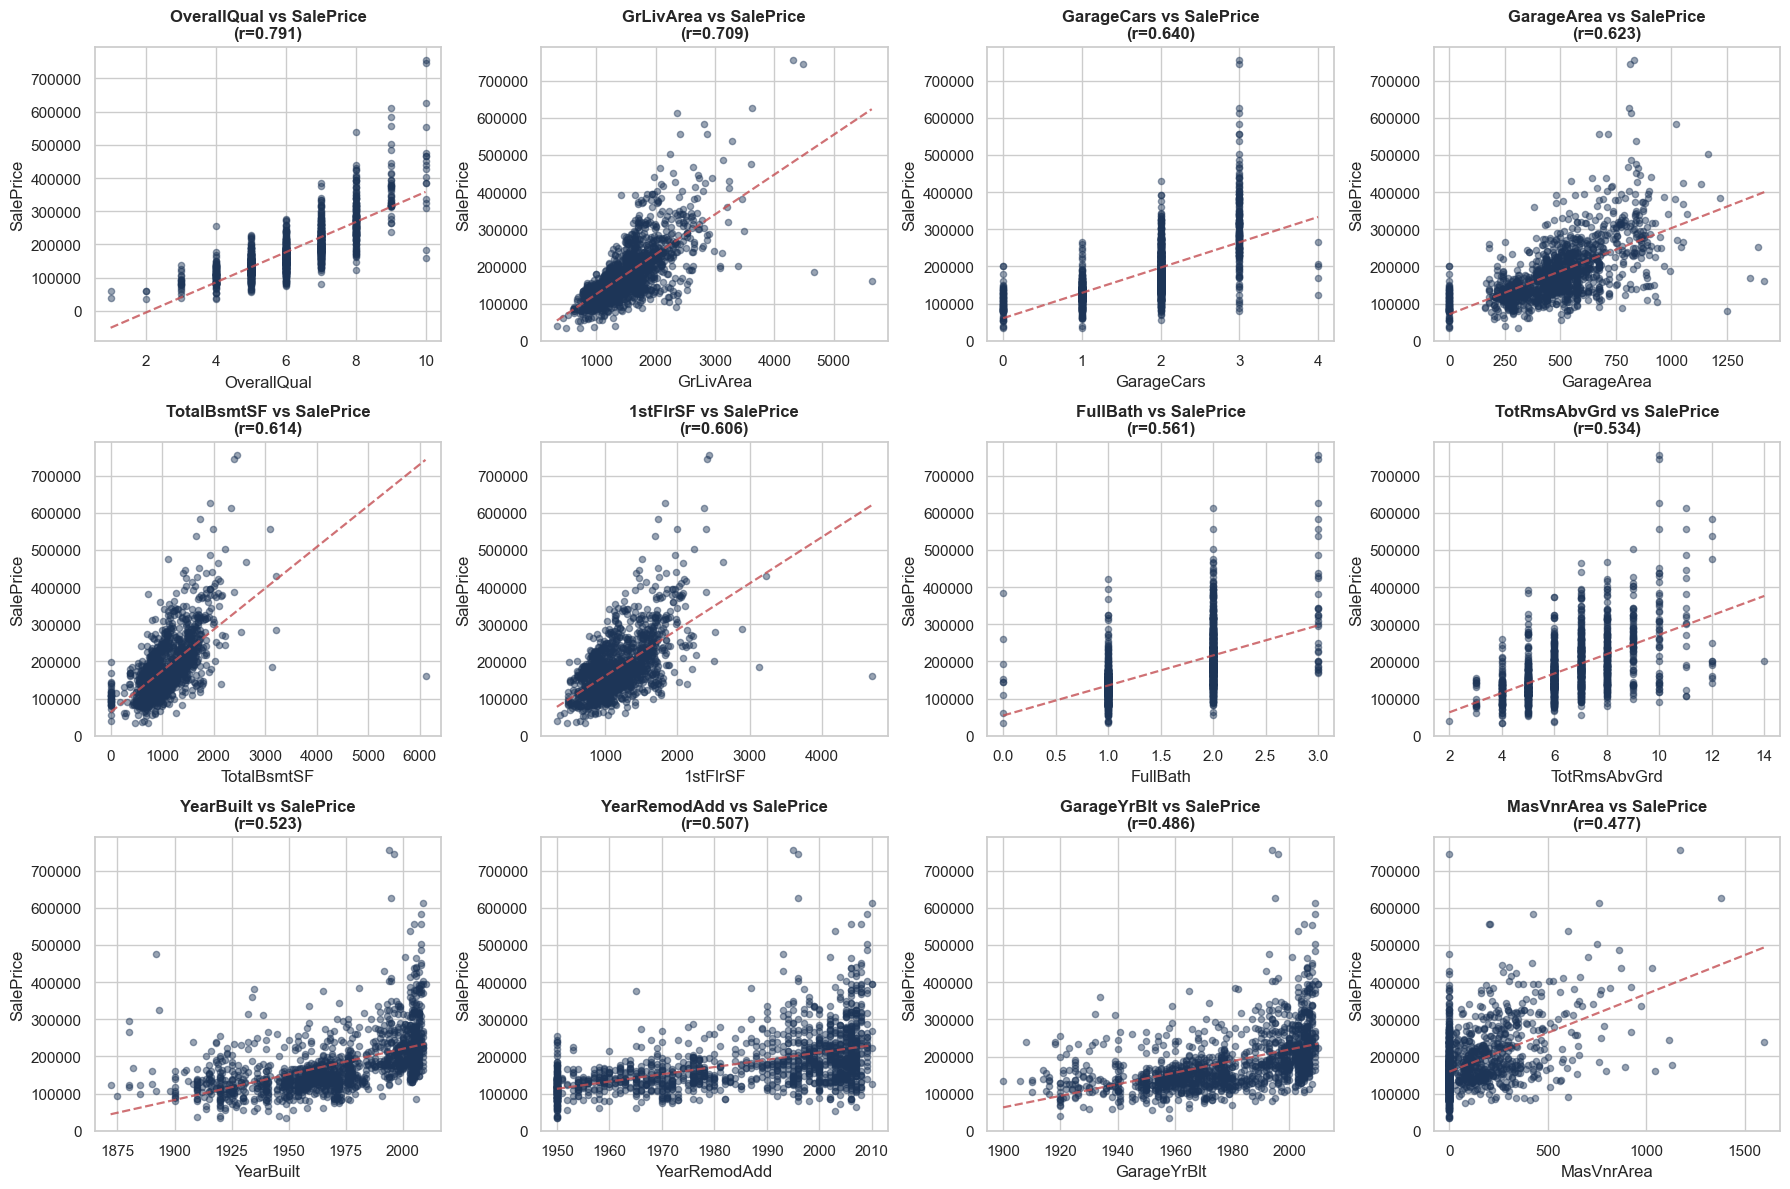

In [59]:
# 4.4 Variables independientes vs variable dependiente
top_features = correlations_with_target.drop(target_col).abs().nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df[target_col], alpha=0.45, s=20, color="#1d3557")
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel(target_col)
    axes[idx].set_title(f"{feature} vs {target_col}\n(r={correlation_matrix.loc[feature, target_col]:.3f})", fontweight="bold")

    tmp = df[[feature, target_col]].dropna()
    if len(tmp) > 1:
        z = np.polyfit(tmp[feature], tmp[target_col], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(tmp[feature].values)
        axes[idx].plot(x_sorted, p(x_sorted), "r--", linewidth=1.6, alpha=0.8)

plt.tight_layout()
plt.show()

## 5. Tratamiento de los datos

En esta seccion se realiza la limpieza final basada en el EDA:
- agrupar categorias raras en `Other`
- eliminar manualmente columnas con muchos faltantes
- imputar faltantes en columnas conservadas
- exportar `clean_train.csv`

### 5.2 Aplicacion de limpieza y exportacion de `clean_train.csv`

### 5.1 Criterios de limpieza aplicados

1. Columnas eliminadas manualmente (segun criterio del analisis):
- `Street`, `Alley`, `Utilities`, `Condition1`, `Condition2`, `RoofMatl`, `MasVnrType`, `Heating`, `Electrical`, `Functional`, `PoolQC`, `Fence`, `MiscFeature`

2. Agrupacion de variables categoricas en `Other`:
- Maximo 4 categorias por columna (se conservan las categorias mas frecuentes y el resto pasa a `Other`).
- Si una categoria domina mas del 70% de la columna, todas las demas se agrupan en `Other`.

3. Imputacion de faltantes en columnas conservadas:
- Numericas: mediana
- Categoricas: `Missing`

4. Restricciones lógicas verificadas:
- Sin casas construidas en futuro
- Sin venta antes de construccion
- Sin `SalePrice` no positivo

In [64]:
# 5.2 Limpieza final y exportacion de clean_train.csv
from pathlib import Path

clean_df = df.copy()

# 1) Eliminar columnas definidas por criterio del EDA
manual_drop_cols = [
    "Street", "Alley", "Utilities", "Condition1", "Condition2",
    "RoofMatl", "MasVnrType", "Heating", "Electrical", "Functional",
    "PoolQC", "Fence", "MiscFeature",
]
manual_drop_cols = [c for c in manual_drop_cols if c in clean_df.columns]
clean_df = clean_df.drop(columns=manual_drop_cols)

# 2) Agrupacion de categoricas: maximo 4 categorias o regla de dominancia >70%
cat_cols_clean = clean_df.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols_clean:
    col_filled = clean_df[col].fillna("Missing")
    vc = col_filled.value_counts(normalize=True, dropna=False)

    if vc.empty:
        continue

    dominant_cat = vc.index[0]
    dominant_share = vc.iloc[0]

    if dominant_share > 0.70 and len(vc) > 1:
        clean_df[col] = np.where(col_filled == dominant_cat, col_filled, "Other")
    elif len(vc) > 4:
        keep_cats = set(vc.index[:3])
        clean_df[col] = np.where(col_filled.isin(keep_cats), col_filled, "Other")
    else:
        clean_df[col] = col_filled

# 3) Imputacion de faltantes en columnas conservadas
num_cols_clean = clean_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_clean = clean_df.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols_clean:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())
for col in cat_cols_clean:
    clean_df[col] = clean_df[col].fillna("Missing")

# 4) Verificaciones finales de calidad
quality_report = pd.DataFrame(
    {
        "metric": [
            "rows",
            "cols",
            "remaining_missing_values",
            "saleprice_non_positive",
            "sold_before_built",
            "yearbuilt_in_future",
        ],
        "value": [
            clean_df.shape[0],
            clean_df.shape[1],
            int(clean_df.isna().sum().sum()),
            int((clean_df["SalePrice"] <= 0).sum()) if "SalePrice" in clean_df.columns else np.nan,
            int((clean_df["YrSold"] < clean_df["YearBuilt"]).sum()) if {"YrSold", "YearBuilt"}.issubset(clean_df.columns) else np.nan,
            int((clean_df["YearBuilt"] > pd.Timestamp.now().year).sum()) if "YearBuilt" in clean_df.columns else np.nan,
        ],
    }
)

# 5) Exportar archivo limpio
output_path = Path("../data/processed/clean_train.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(output_path, index=False)

print("Columnas eliminadas manualmente:", manual_drop_cols)
print(f"Archivo limpio exportado en: {output_path}")
display(quality_report.head(10))

Columnas eliminadas manualmente: ['Street', 'Alley', 'Utilities', 'Condition1', 'Condition2', 'RoofMatl', 'MasVnrType', 'Heating', 'Electrical', 'Functional', 'PoolQC', 'Fence', 'MiscFeature']
Archivo limpio exportado en: ..\data\processed\clean_train.csv


,metric,value
0,rows,1460
1,cols,68
2,remaining_missing_values,0
3,saleprice_non_positive,0
4,sold_before_built,0
5,yearbuilt_in_future,0


### 5.3 Verificacion del dataset limpio

Revision final de muestra, tipos de datos y faltantes residuales tras la limpieza.

In [65]:
# 5.3 Vista final del dataset limpio
print("Preview clean_df:")
display(clean_df.head(10))

print("Tipos de datos del dataset limpio (top 20):")
display(clean_df.dtypes.astype(str).to_frame("dtype").head(20))

print("Resumen de faltantes tras limpieza (debe ser 0):")
print(clean_df.isna().sum().sum())

print("Dimensiones del dataset limpio:", clean_df.shape)

Preview clean_df:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,1Fam,2Story,7,5,2003,2003,Gable,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,Ex,Y,856,854,0,1710,1,0,2,1,3,1,Gd,8,0,Missing,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Reg,Lvl,Other,Gtl,Other,1Fam,1Story,6,8,1976,1976,Gable,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,Ex,Y,1262,0,0,1262,0,1,2,0,3,1,TA,6,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,1Fam,2Story,7,5,2001,2002,Gable,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Other,GLQ,486,Unf,0,434,920,Ex,Y,920,866,0,1786,1,0,2,1,3,1,Gd,6,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,IR1,Lvl,Other,Gtl,Other,1Fam,2Story,7,5,1915,1970,Gable,Other,Other,0.0,TA,TA,BrkTil,TA,Other,No,ALQ,216,Unf,0,540,756,Gd,Y,961,756,0,1717,1,0,1,0,3,1,Gd,7,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Other,140000
4,5,60,RL,84.0,14260,IR1,Lvl,Other,Gtl,Other,1Fam,2Story,8,5,2000,2000,Gable,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,Ex,Y,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,IR1,Lvl,Inside,Gtl,Other,1Fam,1.5Fin,5,5,1993,1995,Gable,VinylSd,VinylSd,0.0,TA,TA,Other,Gd,TA,No,GLQ,732,Unf,0,64,796,Ex,Y,796,566,0,1362,1,0,1,1,1,1,TA,5,0,Missing,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Reg,Lvl,Inside,Gtl,Other,1Fam,1Story,8,5,2004,2005,Gable,VinylSd,VinylSd,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,Ex,Y,1694,0,0,1694,1,0,2,0,3,1,Gd,7,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,0,8,2007,WD,Normal,307000
7,8,60,RL,69.0,10382,IR1,Lvl,Other,Gtl,Other,1Fam,2Story,7,6,1973,1973,Gable,HdBoard,HdBoard,240.0,TA,TA,CBlock,Gd,TA,Other,ALQ,859,Other,32,216,1107,Ex,Y,1107,983,0,2090,1,0,2,1,3,1,TA,7,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,350,11,2009,WD,Normal,200000
8,9,50,Other,51.0,6120,Reg,Lvl,Inside,Gtl,OldTown,1Fam,1.5Fin,7,5,1931,1950,Gable,Other,Other,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,Gd,Y,1022,752,0,1774,0,0,2,0,2,2,TA,8,2,TA,Detchd,1931.0,Unf,2,468,Other,TA,Y,90,0,205,0,0,0,0,4,2008,WD,Other,129900
9,10,190,RL,50.0,7420,Reg,Lvl,Other,Gtl,Other,Other,Other,5,6,1939,1950,Gable,MetalSd,MetalSd,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,Ex,Y,1077,0,0,1077,1,0,1,0,2,2,TA,5,2,TA,Attchd,1939.0,RFn,1,205,Other,TA,Y,0,4,0,0,0,0,0,1,2008,WD,Normal,118000


Tipos de datos del dataset limpio (top 20):


,dtype
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
LotShape,object
LandContour,object
LotConfig,object
LandSlope,object
Neighborhood,object


Resumen de faltantes tras limpieza (debe ser 0):
0
Dimensiones del dataset limpio: (1460, 68)
